# A Metamorfose do Manchester City (2019/20 e 2020/21)
## Como Pep Guardiola Reinventou o Ataque Sem um Centroavante

---

> **Hipótese central:** Comparando as temporadas 2019/20 e 2020/21, o Manchester City passou por uma transformação estrutural: de um modelo centrado em Agüero para um sistema de finalização coletiva, acelerado após a lesão do camisa 10 em outubro de 2020.

---

### Nova Periodização Tática

| Fase | Período | Descrição |
|------|---------|------------|
| **Fase 1 — Referência 19/20** | ago/2019 → jul/2020 | Temporada 2019/20 como base ofensiva com Agüero |
| **Fase 2 — Início 20/21 (6 jogos)** | 12/set → out/2020 | Primeiros 6 jogos de 2020/21 sem Agüero |
| **Fase 3 — Falso 9 Consolidado** | 01/nov/2020 → 23/mai/2021 | Restante da 2020/21, sem centroavante tradicional |

In [2]:
%pip install soccerdata pandas matplotlib mplsoccer

Note: you may need to restart the kernel to use updated packages.


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
from mplsoccer import Pitch, VerticalPitch
import soccerdata as sd

sns.set_theme(style="white", font_scale=1.05)
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

[06/09/26 08:52:15] INFO     No custom team name replacements found. You can configure these in       ]8;id=1537946;file://c:\Users\carolinaabdu\AppData\Local\Programs\Python\Python313\Lib\site-packages\soccerdata\_config.py\_config.py]8;;\:]8;id=1537947;file://c:\Users\carolinaabdu\AppData\Local\Programs\Python\Python313\Lib\site-packages\soccerdata\_config.py#92\92]8;;\
                             C:\Users\carolinaabdu\soccerdata\config\teamname_replacements.json.                   

                    INFO     No custom league dict found. You can configure additional leagues in    ]8;id=1537953;file://c:\Users\carolinaabdu\AppData\Local\Programs\Python\Python313\Lib\site-packages\soccerdata\_config.py\_config.py]8;;\:]8;id=1537954;file://c:\Users\carolinaabdu\AppData\Local\Programs\Python\Python313\Lib\site-packages\soccerdata\_config.py#190\190]8;;\
                             C:\Users\carolinaabdu\soccerdata\config\league_dict.json.                             

## 1. Carregamento dos Dados (2019/20 e 2020/21)

In [4]:
print("Carregando dados do Understat para 2019/20 e 2020/21...")

understat = sd.Understat(leagues="ENG-Premier League", seasons=["1920", "2021"])
all_shots = understat.read_shot_events()
df_shots = all_shots.reset_index()

print(f"Total de chutes carregados: {len(df_shots)}")
print(f"Temporadas: {df_shots['season'].unique() if 'season' in df_shots.columns else 'ver index'}")
print(f"Colunas: {list(df_shots.columns)}")

Carregando dados do Understat para 2019/20 e 2020/21...


                    INFO     Saving cached data to C:\Users\carolinaabdu\soccerdata\data\Understat   ]8;id=1537961;file://c:\Users\carolinaabdu\AppData\Local\Programs\Python\Python313\Lib\site-packages\soccerdata\_common.py\_common.py]8;;\:]8;id=1537962;file://c:\Users\carolinaabdu\AppData\Local\Programs\Python\Python313\Lib\site-packages\soccerdata\_common.py#250\250]8;;\

[2026-06-09 08:52:15] INFO     TLSLibrary:_load_library:397 - Successfully loaded TLS library: C:\Users\carolinaabdu\AppData\Local\Programs\Python\Python313\Lib\site-packages\tls_requests\bin\tls-client-xgo-1.13.1-windows-amd64.dll


                    INFO     Successfully loaded TLS library:                                      ]8;id=1537969;file://c:\Users\carolinaabdu\AppData\Local\Programs\Python\Python313\Lib\site-packages\tls_requests\models\libraries.py\libraries.py]8;;\:]8;id=1537970;file://c:\Users\carolinaabdu\AppData\Local\Programs\Python\Python313\Lib\site-packages\tls_requests\models\libraries.py#397\397]8;;\
                             C:\Users\carolinaabdu\AppData\Local\Programs\Python\Python313\Lib\sit                 
                             e-packages\tls_requests\bin\tls-client-xgo-1.13.1-windows-amd64.dll                   

Total de chutes carregados: 18662
Temporadas: ['1920' '2021']
Colunas: ['league', 'season', 'game', 'team', 'player', 'league_id', 'season_id', 'game_id', 'date', 'shot_id', 'team_id', 'player_id', 'assist_player_id', 'assist_player', 'xg', 'location_x', 'location_y', 'minute', 'body_part', 'situation', 'result']


In [5]:
# Filtrar apenas chutes do Manchester City
mc_shots = df_shots[df_shots['team'].str.contains('Manchester City', case=False, na=False)].copy()

# Garantir formato datetime
mc_shots['date'] = pd.to_datetime(mc_shots['date'])
# Criar coluna match_date (data do jogo) para agregações por partida
mc_shots['match_date'] = mc_shots['date'].dt.date

# Converter coordenadas Understat (0-1) para StatsBomb (0-120 x 0-80)
if 'x_sb' not in mc_shots.columns:
    mc_shots['x_sb'] = mc_shots['location_x'] * 120
    mc_shots['y_sb'] = mc_shots['location_y'] * 80

print(f"Chutes do Manchester City: {len(mc_shots)}")
print(f"Período coberto: {mc_shots['date'].min().date()} → {mc_shots['date'].max().date()}")
mc_shots[['team', 'date', 'player', 'location_x', 'location_y', 'xg', 'result']].head()

Chutes do Manchester City: 1347


Período coberto: 2019-08-10 → 2021-05-23


,team,date,player,location_x,location_y,xg,result
141,Manchester City,2019-08-10 12:30:00,David Silva,0.807,0.36,0.029337,Missed Shot
142,Manchester City,2019-08-10 12:30:00,Gabriel Jesus,0.949,0.437,0.145192,Goal
143,Manchester City,2019-08-10 12:30:00,Gabriel Jesus,0.813,0.571,0.061302,Saved Shot
144,Manchester City,2019-08-10 12:30:00,Kevin De Bruyne,0.855,0.67,0.048481,Saved Shot
145,Manchester City,2019-08-10 12:30:00,Kyle Walker,0.87,0.478,0.042484,Blocked Shot


## 2. Definição das Fases Táticas

In [6]:
# ================================================================
# PERIODIZAÇÃO TÁTICA CORRIGIDA — SEPARAÇÃO COMPLETA (AGÜERO EFFECT)
# ================================================================

# 1. Padronização e parsing de datas diretamente de mc_shots
mc_shots['date_parsed'] = pd.to_datetime(mc_shots['date'])
mc_shots['match_date_key'] = mc_shots['date_parsed'].dt.strftime('%Y-%m-%d')

fase1_label = 'Fase 1 — Agüero titular'
fase2_label = 'Fase 2 — Transição'
fase3_label = 'Fase 3 — Pós-transição'

# 2. Criação dos conjuntos de datas das rodadas exatas da Premier League
# Vamos filtrar as datas diretamente do DataFrame mc_shots separando por períodos reais de calendário

# Temporada 19/20: Jogos que aconteceram antes de setembro de 2020
mc_1920_dates = mc_shots[mc_shots['date_parsed'] < '2020-09-01']['match_date_key'].unique()
mc_1920_dates_sorted = sorted(list(mc_1920_dates))

# Temporada 20/21: Jogos que aconteceram a partir de setembro de 2020
mc_2021_dates = mc_shots[mc_shots['date_parsed'] >= '2020-09-01']['match_date_key'].unique()
mc_2021_dates_sorted = sorted(list(mc_2021_dates))

# Mapeamento manual das posições cronológicas (rodadas reais em que o City jogou de fato)
# Rodadas 19/20 onde Agüero foi titular (Ajustado para o índice 0 do Python)
fase1_idx_1920 = {2-1, 3-1, 4-1, 5-1, 6-1, 8-1, 11-1, 12-1, 13-1, 19-1, 20-1, 22-1, 23-1, 25-1, 26-1, 27-1, 29-1, 30-1}
fase2_idx_1920 = {31-1, 32-1, 33-1, 34-1, 35-1, 36-1, 37-1, 38-1}

# Extração de datas da Fase 1 e início da Fase 2 (19/20)
fase1_dates = {mc_1920_dates_sorted[i] for i in fase1_idx_1920 if i < len(mc_1920_dates_sorted)}
fase2_dates_1920 = {mc_1920_dates_sorted[i] for i in fase2_idx_1920 if i < len(mc_1920_dates_sorted)}

# Fase 2 em 20/21: Os 5 primeiros jogos cronológicos da temporada (Rodadas 1 a 5)
fase2_dates_2021 = set(mc_2021_dates_sorted[:5])

# União da Fase 2 (Fim de 19/20 + Início de 20/21)
fase2_dates = fase2_dates_1920 | fase2_dates_2021

# Fase 3: Todos os jogos restantes de 20/21 (A partir do 6º jogo cronológico)
fase3_dates_todas = set(mc_2021_dates_sorted[5:])

# 3. Limpeza tática: Identificar e remover jogos onde Agüero entrou vindo do banco (Substitutos)
# Rodadas 19/20 onde ele foi reserva:
sub_idx_1920 = {1-1, 7-1, 10-1, 18-1, 24-1, 28-1}
sub_dates_1920 = {mc_1920_dates_sorted[i] for i in sub_idx_1920 if i < len(mc_1920_dates_sorted)}

# Identificação automática em 20/21 de partidas com Agüero em campo (para remover contaminações na Fase 3)
# O Understat marca no campo 'player' quem chutou, se ele estava em campo, limpamos a rodada inteira.
sub_dates_2021 = set(mc_shots[
    (mc_shots['date_parsed'] >= '2020-11-01') & 
    (mc_shots['player'].str.contains('Agüero|Aguero', na=False))
]['match_date_key'].unique())

all_sub_dates = sub_dates_1920 | sub_dates_2021

# Aplicar a limpeza na Fase 3 para deixar o modelo de Falso 9 totalmente consolidado
fase3_dates = fase3_dates_todas - all_sub_dates

# 4. Atribuição das fases no DataFrame principal de finalizações
mc_shots['fase'] = None
mc_shots.loc[mc_shots['match_date_key'].isin(fase1_dates), 'fase'] = fase1_label
mc_shots.loc[mc_shots['match_date_key'].isin(fase2_dates), 'fase'] = fase2_label
mc_shots.loc[mc_shots['match_date_key'].isin(fase3_dates), 'fase'] = fase3_label

# Criação das variáveis globais esperadas pelas células seguintes de gráficos
fase1_matches = mc_shots[mc_shots['fase'] == fase1_label].copy()
fase2_matches = mc_shots[mc_shots['fase'] == fase2_label].copy()
fase3_matches = mc_shots[mc_shots['fase'] == fase3_label].copy()

fase1_ids = fase1_dates
fase2_ids = fase2_dates
fase3_ids = fase3_dates

# 5. Métricas para exibição da tabela de conferência
g1 = mc_shots[mc_shots['fase'] == fase1_label]['match_date_key'].nunique()
g2 = mc_shots[mc_shots['fase'] == fase2_label]['match_date_key'].nunique()
g3 = mc_shots[mc_shots['fase'] == fase3_label]['match_date_key'].nunique()

n1 = len(fase1_matches)
n2 = len(fase2_matches)
n3 = len(fase3_matches)

def safe_rate(chutes, jogos):
    return chutes / jogos if jogos else float('nan')

print("╔══════════════════════════════════════════════════════════════════╗")
print("║    PERIODIZAÇÃO TÁTICA — PROCESSAMENTO DIRETORIZADO COMPLETO     ║")
print("╠══════════════════════════════╦════════╦════════╦════════════════╣")
print("║ Fase                         ║ Chutes ║  Jogos ║ Chutes/jogo    ║")
print("╠══════════════════════════════╬════════╬════════╬════════════════╣")
print(f"║ {fase1_label:<28} ║  {n1:>4}  ║  {g1:>4}  ║     {safe_rate(n1, g1):.2f}        ║")
print(f"║ {fase2_label:<28} ║  {n2:>4}  ║  {g2:>4}  ║     {safe_rate(n2, g2):.2f}        ║")
print(f"║ {fase3_label:<28} ║  {n3:>4}  ║  {g3:>4}  ║     {safe_rate(n3, g3):.2f}        ║")
print("╚══════════════════════════════╩════════╩════════╩════════════════╝")

print(f"Jogos mapeados na Fase 1 (Agüero Titular): {g1} (Esperado: 18)")
print(f"Jogos mapeados na Fase 2 (Transição): {g2} (Esperado: 14)")
print(f"Jogos mapeados na Fase 3 (Falso 9 Consolidado): {g3}")
print(f"Jogos desconsiderados (Contaminação por Agüero reserva): {len(mc_shots.loc[mc_shots['match_date_key'].isin(all_sub_dates), 'match_date_key'].drop_duplicates())}")

cores_fase = {
    fase1_label: '#D94801',
    fase2_label: '#94A3B8',
    fase3_label: '#08519C'
}
fase_order = [fase1_label, fase2_label, fase3_label]

╔══════════════════════════════════════════════════════════════════╗
║    PERIODIZAÇÃO TÁTICA — PROCESSAMENTO DIRETORIZADO COMPLETO     ║
╠══════════════════════════════╦════════╦════════╦════════════════╣
║ Fase                         ║ Chutes ║  Jogos ║ Chutes/jogo    ║
╠══════════════════════════════╬════════╬════════╬════════════════╣
║ Fase 1 — Agüero titular      ║   361  ║    18  ║     20.06        ║
║ Fase 2 — Transição           ║   245  ║    13  ║     18.85        ║
║ Fase 3 — Pós-transição       ║   390  ║    25  ║     15.60        ║
╚══════════════════════════════╩════════╩════════╩════════════════╝
Jogos mapeados na Fase 1 (Agüero Titular): 18 (Esperado: 18)
Jogos mapeados na Fase 2 (Transição): 13 (Esperado: 14)
Jogos mapeados na Fase 3 (Falso 9 Consolidado): 25
Jogos desconsiderados (Contaminação por Agüero reserva): 14


---
## Seção 1 — Periodização Tática e Mapa de Chutes (Time Completo)

### 1.1 — Comparação entre Fases: 2019/20 (com Agüero) vs. 2020/21 Consolidado (Falso 9)

O primeiro diagnóstico examina **como o padrão de finalizações do City mudou entre as três fases táticas** — sem filtrar por jogadores. O objetivo é identificar se a transição sistêmica alterou as zonas de finalização ou apenas a composição dos executores.

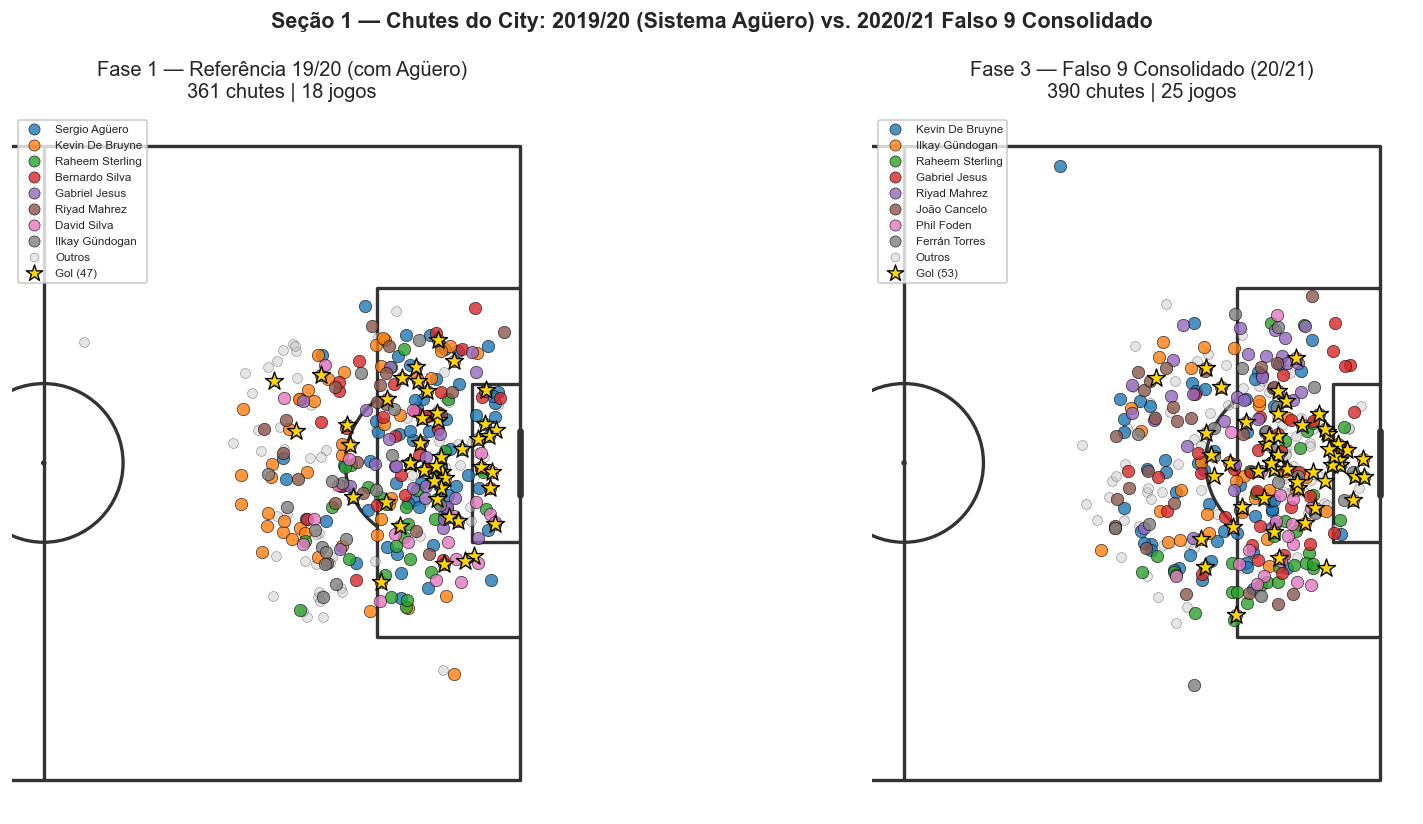

In [7]:
fase1_shots = mc_shots[mc_shots['fase'] == fase1_label].copy()
fase3_shots = mc_shots[mc_shots['fase'] == fase3_label].copy()

pitch = Pitch(pitch_type='statsbomb', half=True, pitch_color='white', line_color='#333333')
fig, ax = pitch.draw(figsize=(16, 7), nrows=1, ncols=2)
fig.set_facecolor('white')
fig.suptitle(
    'Seção 1 — Chutes do City: 2019/20 (Sistema Agüero) vs. 2020/21 Falso 9 Consolidado',
    fontsize=13, fontweight='bold'
)

for a, data, titulo in [
    (ax[0], fase1_shots,
     f'Fase 1 — Referência 19/20 (com Agüero)\n{len(fase1_shots)} chutes | {g1} jogos'),
    (ax[1], fase3_shots,
     f'Fase 3 — Falso 9 Consolidado (20/21)\n{len(fase3_shots)} chutes | {g3} jogos'),
]:
    top_players = data['player'].value_counts().head(8).index.tolist()
    palette = sns.color_palette('tab10', len(top_players))
    player_colors = dict(zip(top_players, palette))

    for player in top_players:
        subset = data[data['player'] == player]
        a.scatter(subset['x_sb'], subset['y_sb'], s=55,
                  color=player_colors[player], alpha=0.8,
                  edgecolors='black', linewidth=0.4, label=player, zorder=3)

    others = data[~data['player'].isin(top_players)]
    if len(others) > 0:
        a.scatter(others['x_sb'], others['y_sb'], s=35, color='#cccccc',
                  alpha=0.5, edgecolors='black', linewidth=0.3, label='Outros', zorder=2)

    gols = data[data['result'] == 'Goal']
    a.scatter(gols['x_sb'], gols['y_sb'], s=130, color='gold',
              edgecolors='black', linewidth=0.8, marker='*', zorder=5,
              label=f'Gol ({len(gols)})')

    a.set_title(titulo, fontsize=12, pad=10)
    a.legend(loc='upper left', fontsize=7, frameon=True,
             facecolor='white', edgecolor='silver', markerscale=0.9)

plt.tight_layout()
plt.show()

### Interpretação — Mapa de Chutes por Fase (Time Completo)

**O que o gráfico mostra:** cada ponto representa um chute do Manchester City — os 8 maiores finalizadores de cada fase aparecem com cor própria; os demais em cinza. Estrelas douradas marcam os gols.

**Por que isso importa taticamente:**

- **Fase 1 (19/20 — Sistema com Agüero):** os chutes dos atacantes de ofício (Agüero, Jesus, Sterling) dominam o padrão de finalização. Agüero tende a finalizar pelo corredor central e lado direito da área.

- **Fase 3 (20/21 — Falso 9 Consolidado):** Gündogan, Foden e De Bruyne surgem como protagonistas das finalizações. A distribuição lateral fica mais simétrica — sem um finalizador fixo, o sistema exige que múltiplos jogadores ocupem a zona central.

---
## Seção 2 — O Paradoxo da Estabilidade Espacial

> *"Como o Manchester City alterou radicalmente sua estrutura ofensiva sem alterar significativamente as zonas de finalização?"*

Esta é a pergunta central do estudo. O KDE (estimativa de densidade por kernel) compara a distribuição espacial dos chutes de **todos os jogadores** — sem filtro — entre a Fase 1 (19/20) e a Fase 3 (20/21 consolidado).

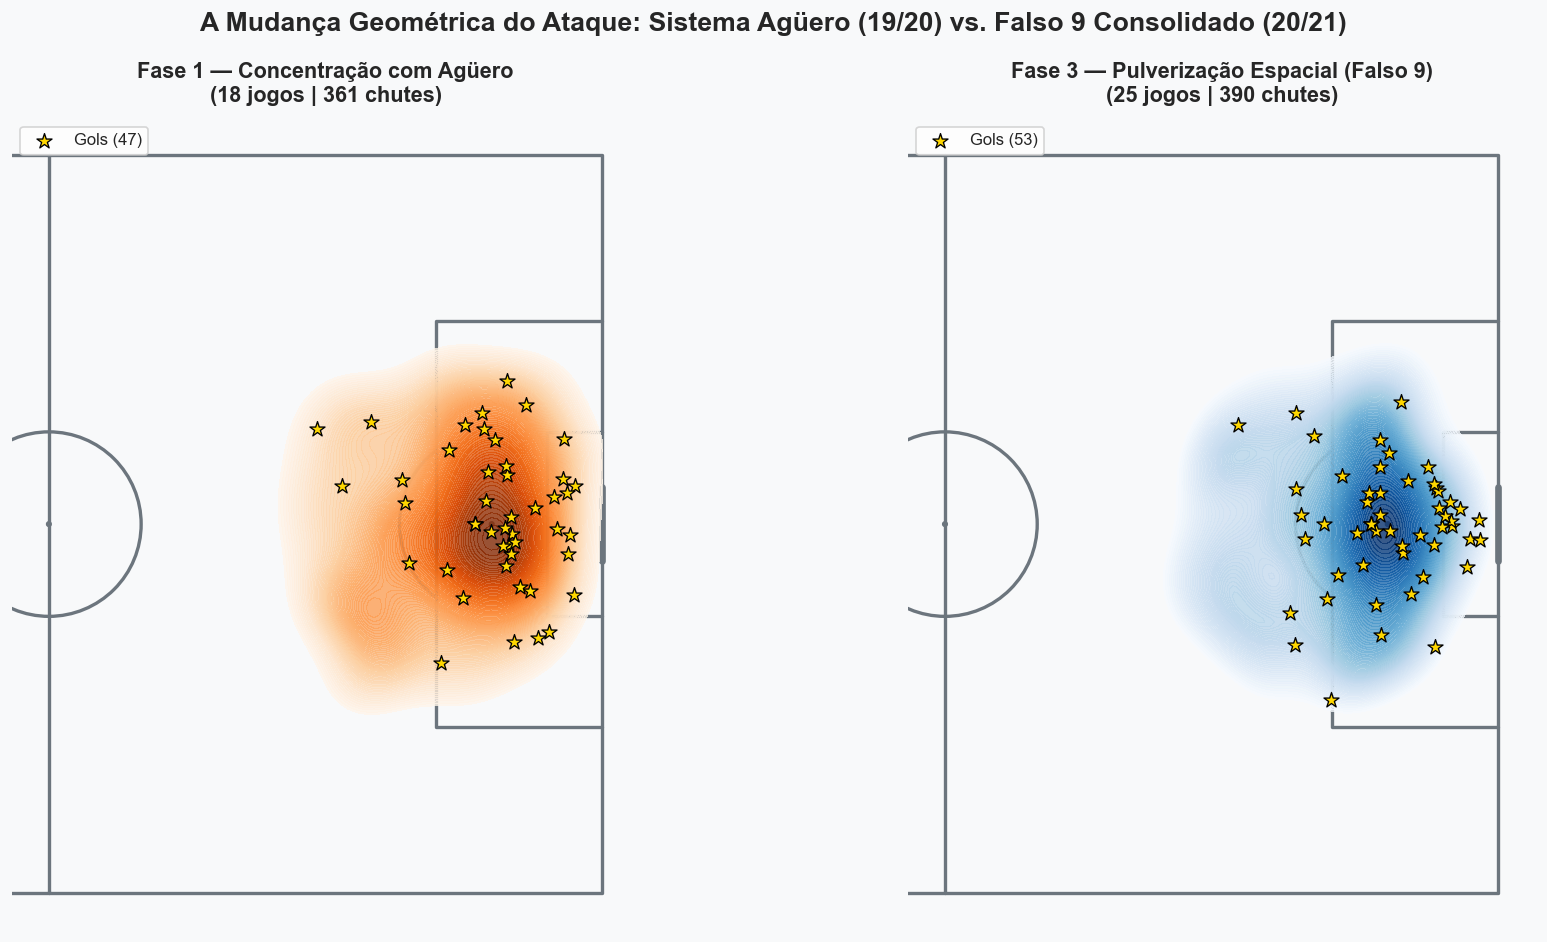

In [8]:
fase1_shots = mc_shots[mc_shots['fase'] == fase1_label].copy()
fase3_shots = mc_shots[mc_shots['fase'] == fase3_label].copy()

pitch = Pitch(pitch_type='statsbomb', half=True, pitch_color='#f8f9fa', line_color='#6c757d')
fig, ax = pitch.draw(figsize=(16, 8), nrows=1, ncols=2)
fig.set_facecolor('#f8f9fa')

fig.suptitle(
    'A Mudança Geométrica do Ataque: Sistema Agüero (19/20) vs. Falso 9 Consolidado (20/21)',
    fontsize=16, fontweight='bold', y=0.98
)

for a, data, titulo, cor in [
    (ax[0], fase1_shots, f'Fase 1 — Concentração com Agüero\n({g1} jogos | {len(fase1_shots)} chutes)', 'Oranges'),
    (ax[1], fase3_shots, f'Fase 3 — Pulverização Espacial (Falso 9)\n({g3} jogos | {len(fase3_shots)} chutes)', 'Blues')
]:
    kde = pitch.kdeplot(data['x_sb'], data['y_sb'], ax=a,
                        cmap=cor, fill=True, levels=100, thresh=0.1, alpha=0.8)
    
    gols = data[data['result'] == 'Goal']
    pitch.scatter(gols['x_sb'], gols['y_sb'], ax=a, s=90, color='gold',
                  edgecolors='black', linewidth=0.8, marker='*', zorder=5, label=f'Gols ({len(gols)})')
    
    a.set_title(titulo, fontsize=13, pad=10, fontweight='bold')
    a.legend(loc='upper left', fontsize=10, frameon=True, facecolor='white')

plt.tight_layout()
plt.show()

### Interpretação — Estabilidade Espacial com Redistribuição Lateral

**O que o gráfico confirma:** em ambas as fases, a grande maioria dos chutes se concentra dentro e próximo à grande área — confirmando a premissa de estabilidade espacial do sistema de Guardiola.

**O que mudou entre as fases:**
- **Posicionamento lateral:** Na Fase 1 (19/20), o núcleo de alta densidade tende para o corredor central-direito — zona preferencial de Agüero. Na Fase 3 (20/21), a distribuição se torna mais simétrica em toda a largura da área.
- **Profundidade:** O falso 9 gerou finalizações ligeiramente mais distribuídas dentro da área, com meias chegando de múltiplos ângulos ao invés de um centroavante fixo.

**Conclusão:** O sistema de Guardiola "demanda" a ocupação das mesmas zonas, independentemente do jogador. A zona exerce o papel do centroavante.

---
## Seção 3 — A Redistribuição dos Finalizadores

> *O que realmente mudou não foram as zonas — foi o mapa de responsabilidades.*

### 3.1 — Chutes por Jogador por Jogo (Fase 1 vs. Fase 3)

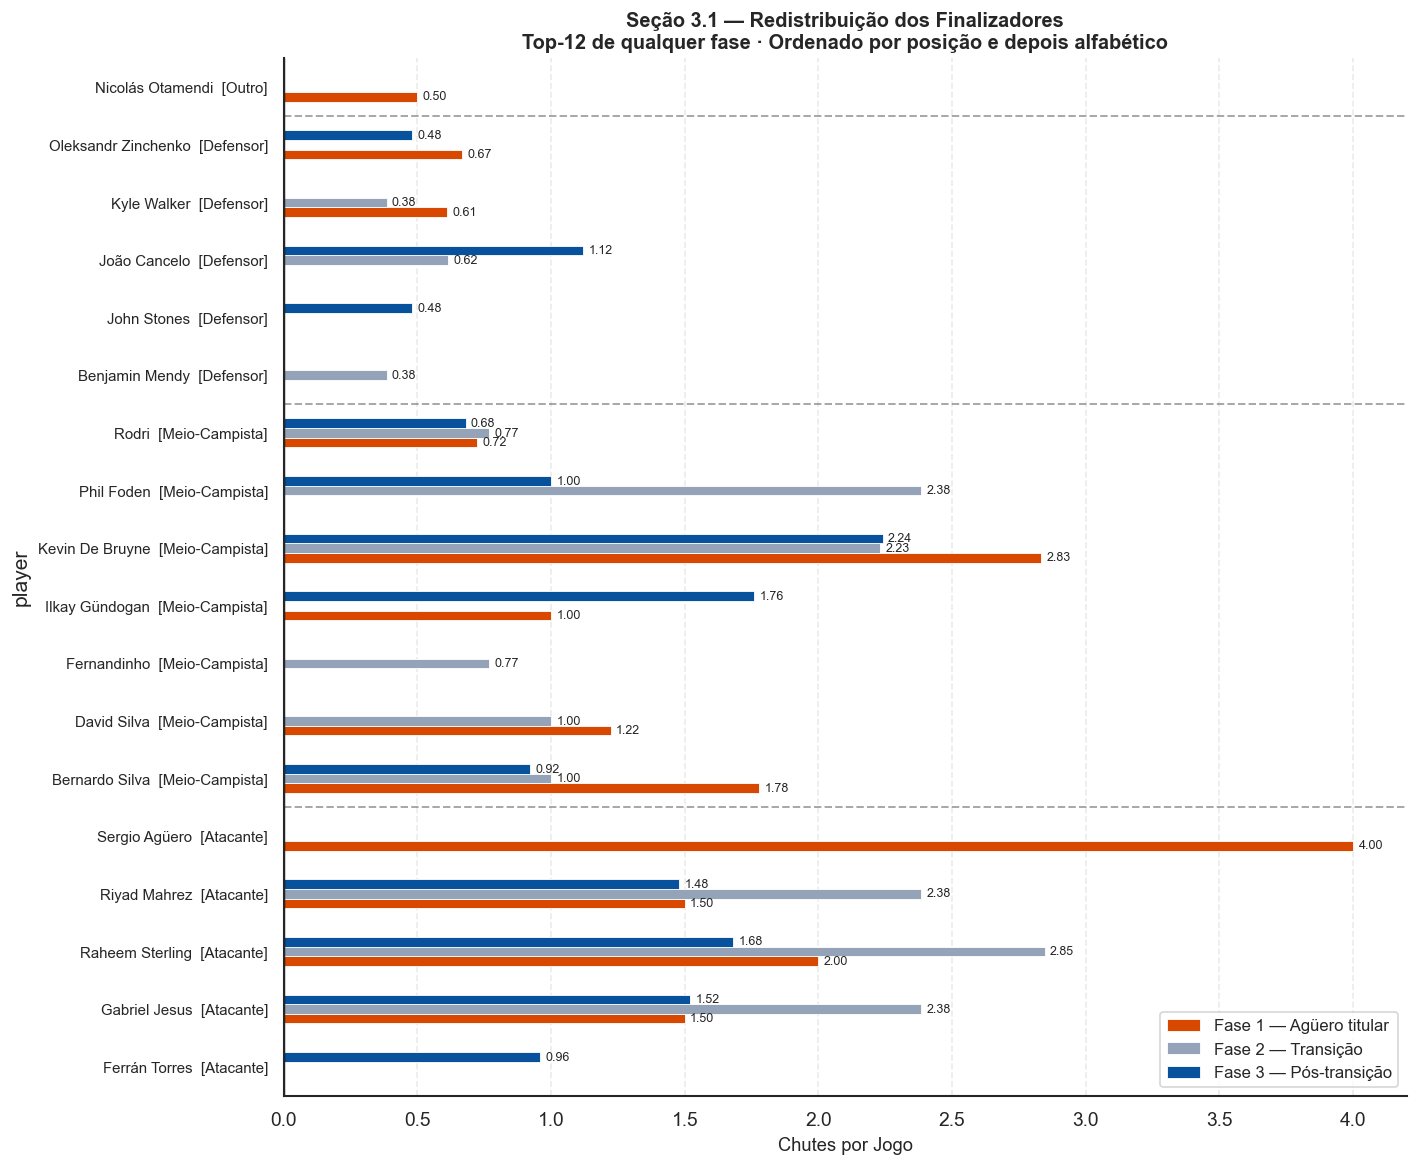


=== Variação de chutes por jogo (Fase 1 → Fase 3) ===
  Ferrán Torres             [Atacante       ]  0.00 → 0.96  ▲ 0.96
  Gabriel Jesus             [Atacante       ]  1.50 → 1.52  ▲ 0.02
  Raheem Sterling           [Atacante       ]  2.00 → 1.68  ▼ 0.32
  Riyad Mahrez              [Atacante       ]  1.50 → 1.48  ▼ 0.02
  Sergio Agüero             [Atacante       ]  4.00 → 0.00  ▼ 4.00
  Bernardo Silva            [Meio-Campista  ]  1.78 → 0.92  ▼ 0.86
  David Silva               [Meio-Campista  ]  1.22 → 0.00  ▼ 1.22
  Fernandinho               [Meio-Campista  ]  0.00 → 0.00  — 0.00
  Ilkay Gündogan            [Meio-Campista  ]  1.00 → 1.76  ▲ 0.76
  Kevin De Bruyne           [Meio-Campista  ]  2.83 → 2.24  ▼ 0.59
  Phil Foden                [Meio-Campista  ]  0.00 → 1.00  ▲ 1.00
  Rodri                     [Meio-Campista  ]  0.72 → 0.68  ▼ 0.04
  Benjamin Mendy            [Defensor       ]  0.00 → 0.00  — 0.00
  John Stones               [Defensor       ]  0.00 → 0.48  ▲ 0.48
  João 

In [9]:
fase1_shots = mc_shots[mc_shots['fase'] == fase1_label].copy()
fase3_shots = mc_shots[mc_shots['fase'] == fase3_label].copy()

player_positions_local = {
    'Ederson': 'Goleiro', 'Zack Steffen': 'Goleiro',
    'Kyle Walker': 'Defensor', 'João Cancelo': 'Defensor',
    'Benjamin Mendy': 'Defensor', 'Rúben Dias': 'Defensor',
    'John Stones': 'Defensor', 'Aymeric Laporte': 'Defensor',
    'Nathan Aké': 'Defensor', 'Eric García': 'Defensor',
    'Oleksandr Zinchenko': 'Defensor',
    'Fernandinho': 'Meio-Campista', 'Rodri': 'Meio-Campista',
    'Ilkay Gündogan': 'Meio-Campista', 'Kevin De Bruyne': 'Meio-Campista',
    'Bernardo Silva': 'Meio-Campista', 'Phil Foden': 'Meio-Campista',
    'David Silva': 'Meio-Campista',
    'Sergio Agüero': 'Atacante', 'Gabriel Jesus': 'Atacante',
    'Raheem Sterling': 'Atacante', 'Riyad Mahrez': 'Atacante',
    'Ferrán Torres': 'Atacante', 'Ferran Torres': 'Atacante',
    'Leroy Sané': 'Atacante',
}
pos_order_local = {'Atacante': 0, 'Meio-Campista': 1, 'Defensor': 2, 'Goleiro': 3, 'Outro': 4}

def get_pos_local(player):
    return player_positions_local.get(player, 'Outro')

# Top-12 de CADA fase individualmente
spg_f1 = (fase1_shots.groupby('player').size() / g1).sort_values(ascending=False).head(12)
spg_f2 = (fase2_matches.groupby('player').size() / g2).sort_values(ascending=False).head(12)
spg_f3 = (fase3_shots.groupby('player').size() / g3).sort_values(ascending=False).head(12)

# União: se aparece no top-12 de QUALQUER fase, aparece em TODAS as fases
all_players_set = set(spg_f1.index) | set(spg_f2.index) | set(spg_f3.index)

# Ordenar: 1º por posição, 2º alfabético dentro de cada posição
all_players_sorted = sorted(all_players_set, key=lambda p: (pos_order_local.get(get_pos_local(p), 4), p))

comp = pd.DataFrame({
    fase1_label: spg_f1.reindex(all_players_sorted, fill_value=0),
    fase2_label: spg_f2.reindex(all_players_sorted, fill_value=0),
    fase3_label: spg_f3.reindex(all_players_sorted, fill_value=0),
})

cores_bars = [cores_fase[f] for f in [fase1_label, fase2_label, fase3_label]]
fig, ax = plt.subplots(figsize=(12, max(9, len(all_players_sorted) * 0.55)))
comp.plot(kind='barh', ax=ax, color=cores_bars, edgecolor='white', linewidth=0.5)

# Separadores entre grupos de posição
prev_pos = None
for i, player in enumerate(all_players_sorted):
    pos = get_pos_local(player)
    if pos != prev_pos and i > 0:
        ax.axhline(y=i - 0.5, color='#555555', linewidth=1.2, linestyle='--', alpha=0.5)
    prev_pos = pos

ytick_labels = [f'{p}  [{get_pos_local(p)}]' for p in all_players_sorted]
ax.set_yticks(range(len(all_players_sorted)))
ax.set_yticklabels(ytick_labels, fontsize=9)

ax.set_xlabel('Chutes por Jogo', fontsize=11)
ax.set_title(
    'Seção 3.1 — Redistribuição dos Finalizadores\n'
    'Top-12 de qualquer fase · Ordenado por posição e depois alfabético',
    fontsize=12, fontweight='bold'
)
ax.axvline(x=0, color='black', linewidth=0.8)
ax.legend(fontsize=10)
ax.xaxis.grid(True, linestyle='--', alpha=0.4)

for bar in ax.patches:
    width = bar.get_width()
    if width > 0.05:
        ax.text(width + 0.02, bar.get_y() + bar.get_height() / 2,
                f'{width:.2f}', va='center', fontsize=7.5)

plt.tight_layout()
plt.show()

print("\n=== Variação de chutes por jogo (Fase 1 → Fase 3) ===")
for p in all_players_sorted:
    v1 = spg_f1.get(p, 0)
    v3 = spg_f3.get(p, 0)
    delta = v3 - v1
    tag = "▲" if delta > 0 else ("▼" if delta < 0 else "—")
    print(f"  {p:<25} [{get_pos_local(p):<15}]  {v1:.2f} → {v3:.2f}  {tag} {abs(delta):.2f}")

### 3.2 — Análise por Grupo Posicional

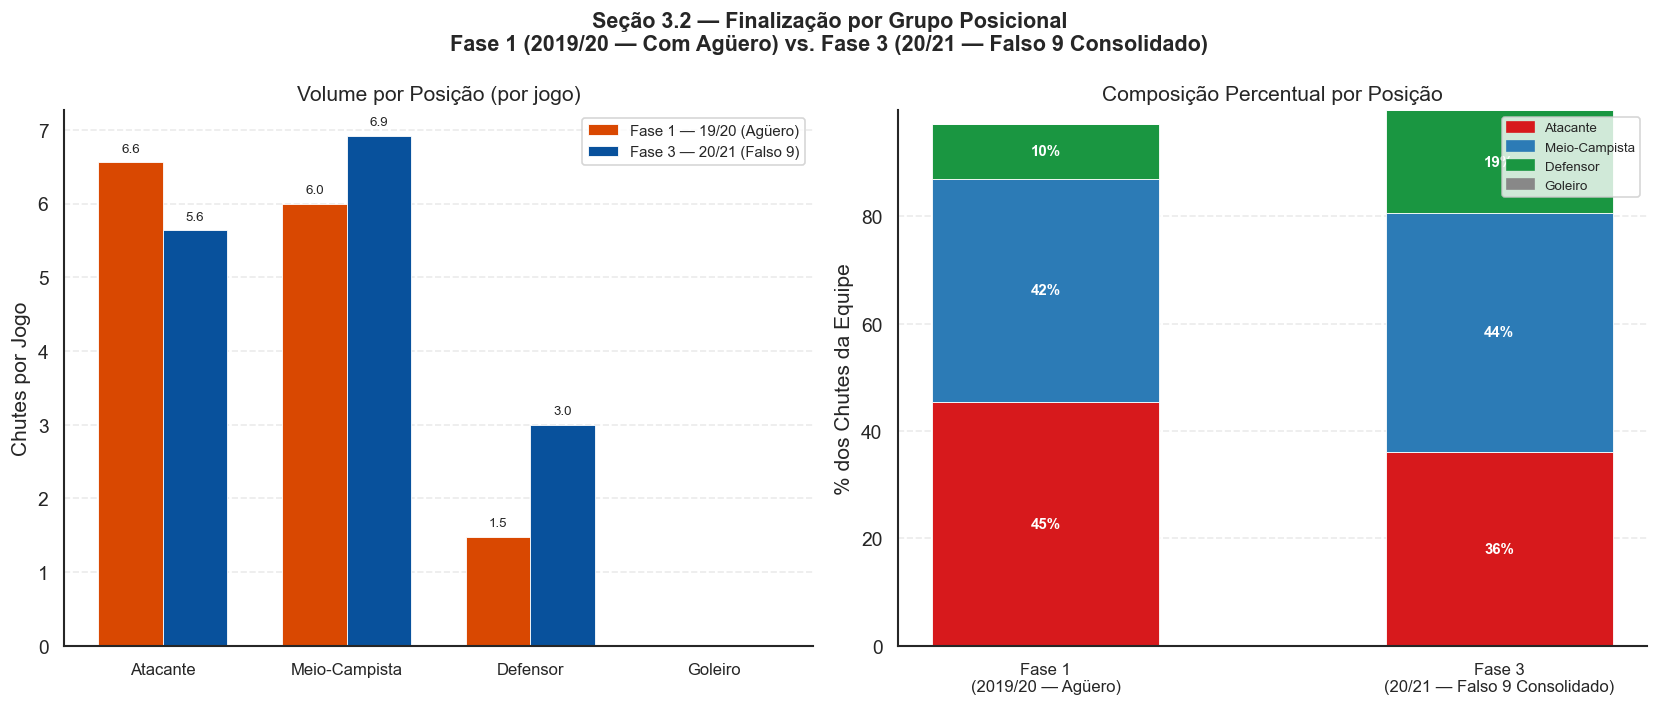


=== Chutes por jogo por posição ===
fase            Fase 1 — Agüero titular  Fase 3 — Pós-transição
position_group                                                 
Atacante                           6.56                    5.64
Defensor                           1.48                    3.00
Meio-Campista                      6.00                    6.92

=== Participação percentual por posição ===
fase            Fase 1 — Agüero titular  Fase 3 — Pós-transição
position_group                                                 
Atacante                           45.4                    36.2
Defensor                           10.2                    19.2
Meio-Campista                      41.6                    44.4


In [10]:
position_map = {
    'Ederson': 'Goleiro', 'Zack Steffen': 'Goleiro',
    'Kyle Walker': 'Defensor', 'João Cancelo': 'Defensor',
    'Benjamin Mendy': 'Defensor', 'Rúben Dias': 'Defensor',
    'John Stones': 'Defensor', 'Aymeric Laporte': 'Defensor',
    'Nathan Aké': 'Defensor', 'Eric García': 'Defensor',
    'Oleksandr Zinchenko': 'Defensor',
    'Fernandinho': 'Meio-Campista', 'Rodri': 'Meio-Campista',
    'Ilkay Gündogan': 'Meio-Campista', 'Kevin De Bruyne': 'Meio-Campista',
    'Bernardo Silva': 'Meio-Campista', 'Phil Foden': 'Meio-Campista',
    'David Silva': 'Meio-Campista',
    'Sergio Agüero': 'Atacante', 'Gabriel Jesus': 'Atacante',
    'Raheem Sterling': 'Atacante', 'Riyad Mahrez': 'Atacante',
    'Ferrán Torres': 'Atacante', 'Ferran Torres': 'Atacante',
    'Leroy Sané': 'Atacante',
}

mc_shots['position_group'] = mc_shots['player'].map(position_map).fillna('Outro')

fase_compare = mc_shots[mc_shots['fase'].isin([fase1_label, fase3_label])].copy()
shots_by_pos = (
    fase_compare.groupby(['fase', 'position_group'])
    .size()
    .reset_index(name='shots')
)
shots_by_pos['shots_per_game'] = shots_by_pos.apply(
    lambda r: r['shots'] / g1 if r['fase'] == 'Fase 1 — Referência 19/20' else r['shots'] / g3,
    axis=1
)
shots_by_pos['pct'] = shots_by_pos['shots'] / shots_by_pos.groupby('fase')['shots'].transform('sum') * 100

pos_order_vis = ['Atacante', 'Meio-Campista', 'Defensor', 'Goleiro']
shots_by_pos = shots_by_pos[shots_by_pos['position_group'].isin(pos_order_vis)].copy()
shots_by_pos['position_group'] = pd.Categorical(
    shots_by_pos['position_group'], categories=pos_order_vis, ordered=True
)

f1_col = 'Fase 1 — Agüero titular'
f3_col = 'Fase 3 — Pós-transição'

pivot_vol = shots_by_pos.pivot(index='position_group', columns='fase', values='shots_per_game').fillna(0)
pivot_pct = shots_by_pos.pivot(index='position_group', columns='fase', values='pct').fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(
    'Seção 3.2 — Finalização por Grupo Posicional\n'
    'Fase 1 (2019/20 — Com Agüero) vs. Fase 3 (20/21 — Falso 9 Consolidado)',
    fontsize=13, fontweight='bold'
)

x = np.arange(len(pos_order_vis))
width = 0.35
ax1 = axes[0]
v1 = [pivot_vol.loc[p, f1_col] if (p in pivot_vol.index and f1_col in pivot_vol.columns) else 0 for p in pos_order_vis]
v3 = [pivot_vol.loc[p, f3_col] if (p in pivot_vol.index and f3_col in pivot_vol.columns) else 0 for p in pos_order_vis]
b1 = ax1.bar(x - width/2, v1, width, label='Fase 1 — 19/20 (Agüero)', color='#D94801', edgecolor='white', linewidth=0.5)
b2 = ax1.bar(x + width/2, v3, width, label='Fase 3 — 20/21 (Falso 9)', color='#08519C', edgecolor='white', linewidth=0.5)
ax1.set_xticks(x)
ax1.set_xticklabels(pos_order_vis, fontsize=10)
ax1.set_ylabel('Chutes por Jogo')
ax1.set_title('Volume por Posição (por jogo)')
ax1.legend(fontsize=9)
ax1.yaxis.grid(True, linestyle='--', alpha=0.4)
for bar in list(b1) + list(b2):
    if bar.get_height() > 0.3:
        ax1.text(
            bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
            f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=8
        )

ax2 = axes[1]
cores_pos = {'Atacante': '#d7191c', 'Meio-Campista': '#2c7bb6', 'Defensor': '#1a9641', 'Goleiro': '#888888'}
bottom1, bottom2 = 0.0, 0.0
handles = []
for pos in pos_order_vis:
    pv1 = pivot_pct.loc[pos, f1_col] if (pos in pivot_pct.index and f1_col in pivot_pct.columns) else 0
    pv3 = pivot_pct.loc[pos, f3_col] if (pos in pivot_pct.index and f3_col in pivot_pct.columns) else 0
    ax2.bar(0, pv1, bottom=bottom1, color=cores_pos[pos], edgecolor='white', linewidth=0.5, width=0.5)
    ax2.bar(1, pv3, bottom=bottom2, color=cores_pos[pos], edgecolor='white', linewidth=0.5, width=0.5)
    handles.append(mpatches.Patch(color=cores_pos[pos], label=pos))
    if pv1 > 3:
        ax2.text(0, bottom1 + pv1 / 2, f'{pv1:.0f}%', ha='center', va='center',
                 fontsize=9, color='white', fontweight='bold')
    if pv3 > 3:
        ax2.text(1, bottom2 + pv3 / 2, f'{pv3:.0f}%', ha='center', va='center',
                 fontsize=9, color='white', fontweight='bold')
    bottom1 += pv1
    bottom2 += pv3

ax2.set_xticks([0, 1])
ax2.set_xticklabels(['Fase 1\n(2019/20 — Agüero)', 'Fase 3\n(20/21 — Falso 9 Consolidado)'], fontsize=10)
ax2.set_ylabel('% dos Chutes da Equipe')
ax2.set_title('Composição Percentual por Posição')
ax2.legend(handles=handles, loc='upper right', fontsize=8)
ax2.yaxis.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

print("\n=== Chutes por jogo por posição ===")
print(pivot_vol.round(2).to_string())
print("\n=== Participação percentual por posição ===")
print(pivot_pct.round(1).to_string())

---
## Seção 4 — Concentração Ofensiva: O Índice de Dependência do Finalizador

### 4.1 — Índice Herfindahl-Hirschman (HHI) Aplicado às Finalizações

O **Índice Herfindahl-Hirschman (HHI)** mede a concentração de finalizações por jogo. Quanto maior o HHI, mais dependente de um único finalizador é o sistema. A hipótese é que o falso 9 reduziu o HHI — evidência de coletivismo ofensivo.

**Interpretação:** HHI → 1.0 = um único jogador faz todos os chutes; HHI → 1/n = distribuição uniforme entre n jogadores.

[06/09/26 08:52:25] WARNING  C:\Users\carolinaabdu\AppData\Local\Temp\ipykernel_51808\331922888.py: ]8;id=1537977;file://c:\Users\carolinaabdu\AppData\Local\Programs\Python\Python313\Lib\warnings.py\warnings.py]8;;\:]8;id=1537978;file://c:\Users\carolinaabdu\AppData\Local\Programs\Python\Python313\Lib\warnings.py#110\110]8;;\
                             14: DeprecationWarning: DataFrameGroupBy.apply operated on the                        
                             grouping columns. This behavior is deprecated, and in a future version                
                             of pandas the grouping columns will be excluded from the operation.                   
                             Either pass `include_groups=False` to exclude the groupings or                        
                             explicitly select the grouping columns after groupby to silence this                  
                             warning.                                                                              
                               .apply(hhi)                                                                         
                                                                                                                   

=== HHI médio por fase ===
                             mean    median       std
fase                                                 
Fase 1 — Agüero titular  0.182192  0.162647  0.097074
Fase 2 — Transição       0.174250  0.157025  0.063629
Fase 3 — Pós-transição   0.187250  0.173554  0.060653

Interpretação: HHI mais baixo = finalizações mais distribuídas (menos concentradas)


NameError: name 'DATA_LESAO' is not defined

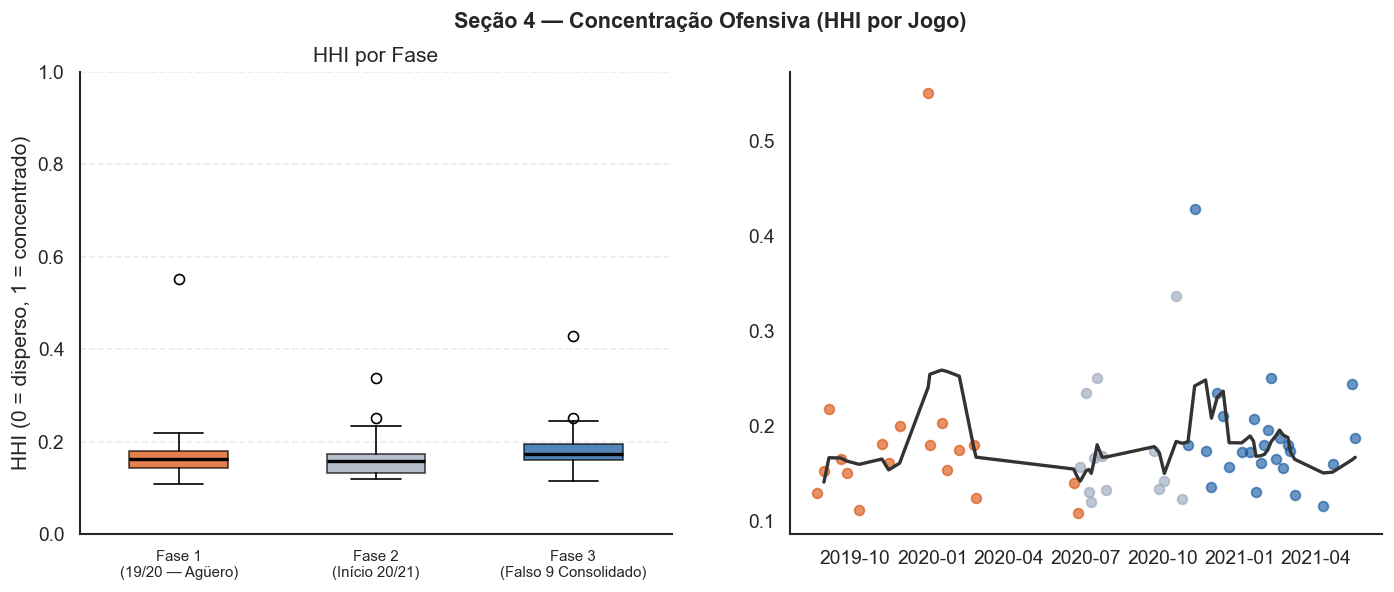

In [11]:
def hhi(group):
    shots_by_player = group.groupby('player').size()
    total = shots_by_player.sum()
    if total == 0:
        return np.nan
    shares = shots_by_player / total
    return (shares ** 2).sum()

# Excluir linhas sem fase definida
mc_shots_valid = mc_shots[mc_shots['fase'].notna()].copy()

hhi_per_game = (
    mc_shots_valid.groupby(['match_date', 'fase'])
    .apply(hhi)
    .reset_index(name='hhi')
)

hhi_summary = hhi_per_game.groupby('fase')['hhi'].agg(['mean', 'median', 'std'])
print("=== HHI médio por fase ===")
print(hhi_summary.reindex(fase_order))
print("\nInterpretação: HHI mais baixo = finalizações mais distribuídas (menos concentradas)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Seção 4 — Concentração Ofensiva (HHI por Jogo)', fontsize=13, fontweight='bold')

ax = axes[0]
for i, fase in enumerate(fase_order):
    dados = hhi_per_game[hhi_per_game['fase'] == fase]['hhi'].dropna()
    ax.boxplot(dados, positions=[i], widths=0.5,
               patch_artist=True,
               boxprops=dict(facecolor=cores_fase[fase], alpha=0.7),
               medianprops=dict(color='black', linewidth=2))
ax.set_xticks(range(len(fase_order)))
ax.set_xticklabels(
    ['Fase 1\n(19/20 — Agüero)', 'Fase 2\n(Início 20/21)', 'Fase 3\n(Falso 9 Consolidado)'],
    fontsize=9
)
ax.set_ylabel('HHI (0 = disperso, 1 = concentrado)')
ax.set_title('HHI por Fase')
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_ylim(0, 1)

ax2 = axes[1]
hhi_trend = hhi_per_game.copy()
hhi_trend['match_date'] = pd.to_datetime(hhi_trend['match_date'])
hhi_trend = hhi_trend.sort_values('match_date')

rolling_window = hhi_trend['hhi'].rolling(window=5, min_periods=2).mean()
ax2.plot(hhi_trend['match_date'], rolling_window, color='#333333', linewidth=2, label='Média móvel (5 jogos)')

for fase in fase_order:
    sub = hhi_trend[hhi_trend['fase'] == fase]
    ax2.scatter(sub['match_date'], sub['hhi'], color=cores_fase[fase], s=35, alpha=0.6, label=fase)

# Linhas de marco temporal
DATA_VIRADA = pd.Timestamp('2021-01-03')
for data_linha, label in [
    (DATA_LESAO, 'Lesão Agüero (out/2020)'),
    (DATA_VIRADA, 'Virada Tática (jan/2021)'),
]:
    ax2.axvline(data_linha, color='red', linestyle='--', linewidth=1.2, alpha=0.8, label=label)

ax2.set_ylabel('HHI por Jogo')
ax2.set_title('Evolução Temporal do HHI\n(tendência de queda = maior coletivismo ofensivo)')
ax2.legend(fontsize=8)
ax2.set_ylim(0, 1)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

---
## Seção 5 — Estudo de Caso: A Metamorfose de İlkay Gündogan

> *"Gündogan não se tornou um centroavante. Ele se tornou o ponto de chegada de um sistema que não precisava de centroavante."*

İlkay Gündogan é o estudo de caso mais revelador desta análise. Contratado como meia posicional e de construção, tornou-se o maior artilheiro do City na segunda metade de 2020/21 — numa temporada em que atuou apenas como meia. A pergunta central é: foi overperformance isolada, ou evidência de uma mudança real no seu papel tático?

=== Gündogan — progressão mensal (2019/20 + 2020/21) ===
mes_str  chutes  xg_total  gols
2019-08       3  0.186139     0
2019-09       3  0.948489     0
2019-10       5  0.238262     1
2019-11       9    0.3164     0
2019-12       3  0.796916     1
2020-01       2  0.037843     0
2020-02       4  1.697824     0
2020-06       1  0.032986     0
2020-07       2  0.091844     0
2020-10       2  0.089163     0
2020-11       1  0.013646     0
2020-12       8  1.221473     2
2021-01      17  2.742182     5
2021-02      10  3.640406     4
2021-03       6  0.898438     1
2021-04       3  0.123747     0
2021-05       7  0.837828     1


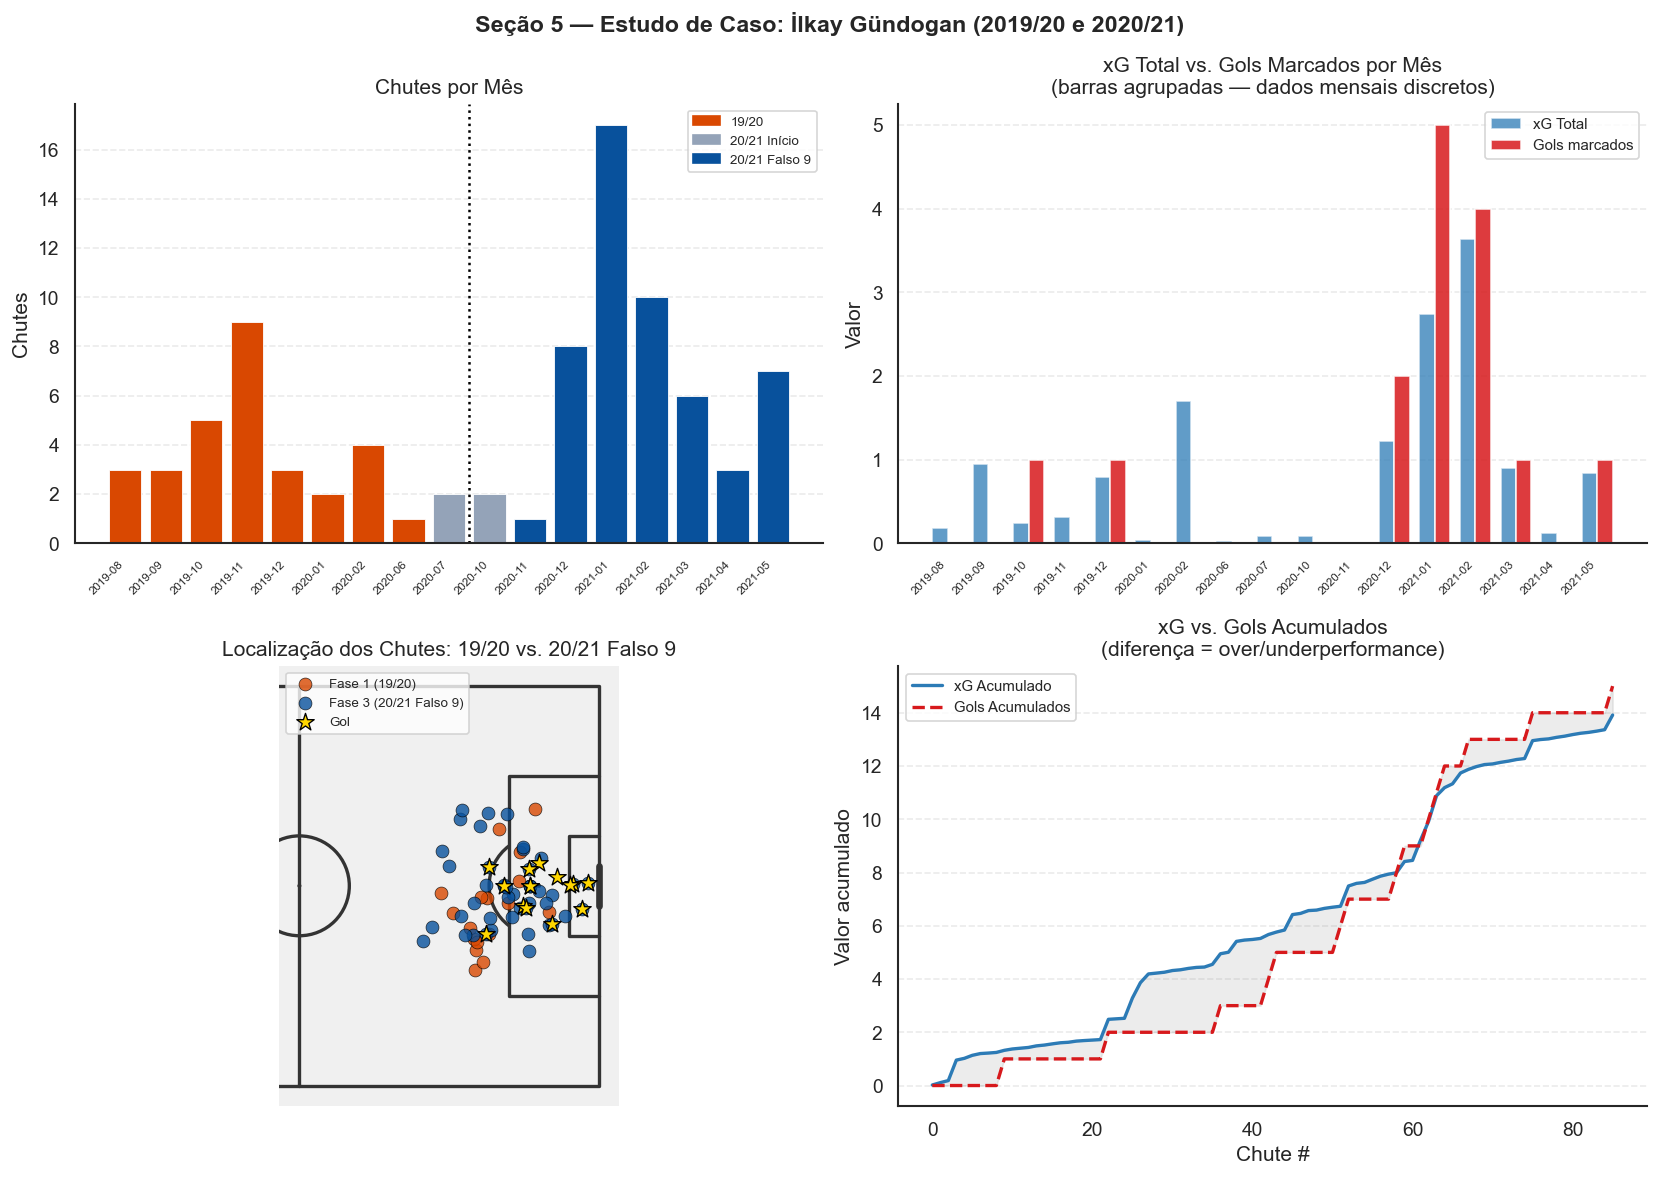


=== Gündogan — duas temporadas ===
Chutes: 86 | xG total: 13.91 | Gols: 15
xG por chute: 0.162 | Gols/xG: 1.08 (>1 = overperformance)

=== Por fase ===
  Fase 1 — Agüero titular: 18 chutes | xG: 2.30 | Gols: 0
  Fase 2 — Transição: 4 chutes | xG: 0.18 | Gols: 0
  Fase 3 — Pós-transição: 44 chutes | xG: 7.64 | Gols: 10


In [12]:
gund_mask = mc_shots['player'].str.contains('Gundogan|Gündoğan|Gündogan', na=False, case=False)
gund = mc_shots[gund_mask].copy()
gund['mes'] = gund['date'].dt.to_period('M')
gund['is_goal'] = (gund['result'] == 'Goal').astype(int)

monthly = gund.groupby('mes').agg(
    chutes=('result', 'count'),
    xg_total=('xg', 'sum'),
    gols=('is_goal', 'sum')
).reset_index()
monthly['mes_str'] = monthly['mes'].astype(str)

print("=== Gündogan — progressão mensal (2019/20 + 2020/21) ===")
print(monthly[['mes_str', 'chutes', 'xg_total', 'gols']].to_string(index=False))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    'Seção 5 — Estudo de Caso: İlkay Gündogan (2019/20 e 2020/21)',
    fontsize=14, fontweight='bold'
)

def classify_month_fixed(mes_str):
    amostra_mes = mc_shots[mc_shots['match_date_key'].str.startswith(mes_str)]
    if len(amostra_mes) > 0:
        fase_predominante = amostra_mes['fase'].value_counts().index[0]
        if fase_predominante == fase1_label:
            return '#D94801'
        elif fase_predominante == fase2_label:
            return '#94A3B8'
        elif fase_predominante == fase3_label:
            return '#08519C'
    return '#94A3B8'

x = range(len(monthly))

ax = axes[0, 0]
bar_colors = [classify_month_fixed(m) for m in monthly['mes_str']]
bars = ax.bar(x, monthly['chutes'], color=bar_colors, edgecolor='white', linewidth=0.5)
ax.set_xticks(x)
ax.set_xticklabels(monthly['mes_str'], rotation=45, ha='right', fontsize=7)
ax.set_ylabel('Chutes')
ax.set_title('Chutes por Mês')
idx_2021 = next((i for i, m in enumerate(monthly['mes_str']) if m >= '2020-09'), None)
if idx_2021 is not None:
    ax.axvline(x=idx_2021 - 0.5, color='black', linestyle=':', linewidth=1.5, label='Início 20/21')
legend_patches = [
    mpatches.Patch(color='#D94801', label='19/20'),
    mpatches.Patch(color='#94A3B8', label='20/21 Início'),
    mpatches.Patch(color='#08519C', label='20/21 Falso 9'),
]
ax.legend(handles=legend_patches, fontsize=8)
ax.yaxis.grid(True, linestyle='--', alpha=0.4)

# Subplot [0,1]: xG vs Gols — barras agrupadas (dados mensais discretos, sem linha contínua)
ax = axes[0, 1]
x_arr = np.array(list(x))
w = 0.38
ax.bar(x_arr - w / 2, monthly['xg_total'], w, color='#2c7bb6', alpha=0.75,
       label='xG Total', edgecolor='white')
ax.bar(x_arr + w / 2, monthly['gols'], w, color='#d7191c', alpha=0.85,
       label='Gols marcados', edgecolor='white')
ax.set_xticks(x_arr)
ax.set_xticklabels(monthly['mes_str'], rotation=45, ha='right', fontsize=7)
ax.set_ylabel('Valor')
ax.set_title('xG Total vs. Gols Marcados por Mês\n(barras agrupadas — dados mensais discretos)')
ax.legend(fontsize=9)
ax.yaxis.grid(True, linestyle='--', alpha=0.4)

ax = axes[1, 0]
pitch_small = Pitch(pitch_type='statsbomb', half=True, pitch_color='#f0f0f0', line_color='#333333')
pitch_small.draw(ax=ax)
gund_f1 = gund[gund['fase'] == fase1_label]
gund_f3 = gund[gund['fase'] == fase3_label]
ax.scatter(gund_f1['x_sb'], gund_f1['y_sb'], s=60, color='#D94801', alpha=0.8,
           edgecolors='black', lw=0.4, label='Fase 1 (19/20)', zorder=3)
ax.scatter(gund_f3['x_sb'], gund_f3['y_sb'], s=60, color='#08519C', alpha=0.8,
           edgecolors='black', lw=0.4, label='Fase 3 (20/21 Falso 9)', zorder=3)
gund_gols = gund[gund['is_goal'] == 1]
ax.scatter(gund_gols['x_sb'], gund_gols['y_sb'], s=120, color='gold',
           edgecolors='black', lw=0.8, marker='*', zorder=4, label='Gol')
ax.set_title('Localização dos Chutes: 19/20 vs. 20/21 Falso 9')
ax.legend(loc='upper left', fontsize=8)

ax = axes[1, 1]
gund_sorted = gund.sort_values('date')
xg_cumulative = gund_sorted['xg'].cumsum()
goals_cumulative = gund_sorted['is_goal'].cumsum()
ax.plot(range(len(gund_sorted)), xg_cumulative.values, color='#2c7bb6', linewidth=2, label='xG Acumulado')
ax.plot(range(len(gund_sorted)), goals_cumulative.values, color='#d7191c', linewidth=2,
        linestyle='--', label='Gols Acumulados')
ax.fill_between(range(len(gund_sorted)), xg_cumulative.values, goals_cumulative.values,
                alpha=0.15, color='gray')
ax.set_xlabel('Chute #')
ax.set_ylabel('Valor acumulado')
ax.set_title('xG vs. Gols Acumulados\n(diferença = over/underperformance)')
ax.legend(fontsize=9)
ax.yaxis.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

total_xg = gund['xg'].sum()
total_gols = gund['is_goal'].sum()
print(f"\n=== Gündogan — duas temporadas ===")
print(f"Chutes: {len(gund)} | xG total: {total_xg:.2f} | Gols: {total_gols}")
print(f"xG por chute: {total_xg/len(gund):.3f} | Gols/xG: {total_gols/total_xg:.2f} (>1 = overperformance)")

print("\n=== Por fase ===")
for fase in [fase1_label, fase2_label, fase3_label]:
    sub = gund[gund['fase'] == fase]
    if len(sub) > 0:
        print(f"  {fase}: {len(sub)} chutes | xG: {sub['xg'].sum():.2f} | Gols: {sub['is_goal'].sum()}")

---
## Seção 6 — Qualidade vs. Quantidade: A Eficiência do Sistema

> *O sistema de falso 9 criou chances de melhor qualidade, ou apenas redistribuiu executores?*

Confirmar a redistribuição e a estabilidade espacial é necessário — mas não suficiente. A pergunta decisiva é se a qualidade das chances geradas se manteve ou melhorou quando o centroavante foi removido do sistema.

=== Métricas de Qualidade de Finalização por Fase ===

                         Chutes  xG médio/chute  Gols  Taxa conversão (%)  % dentro da área  Gols/xG ratio
Fase                                                                                                      
Fase 1 — Agüero titular     361           0.133    47              13.019            60.665          0.977
Fase 2 — Transição          245           0.130    32              13.061            60.816          1.004
Fase 3 — Pós-transição      390           0.131    53              13.590            59.744          1.037


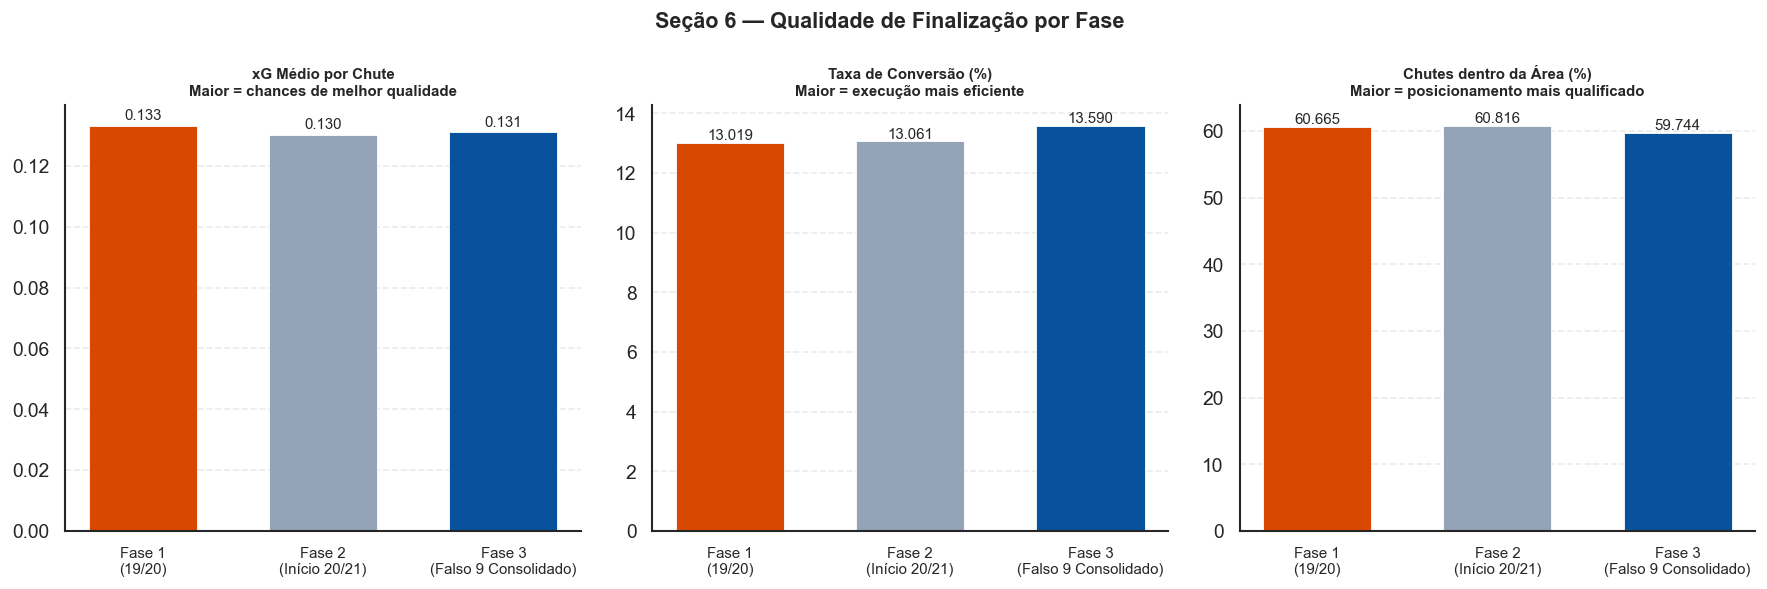


=== Distribuição de xG (boxplot por fase) ===


[06/09/26 08:54:31] WARNING  C:\Users\carolinaabdu\AppData\Local\Temp\ipykernel_51808\234673861.py: ]8;id=1537983;file://c:\Users\carolinaabdu\AppData\Local\Programs\Python\Python313\Lib\warnings.py\warnings.py]8;;\:]8;id=1537984;file://c:\Users\carolinaabdu\AppData\Local\Programs\Python\Python313\Lib\warnings.py#110\110]8;;\
                             63: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot()                 
                             has been renamed 'tick_labels' since Matplotlib 3.9; support for the                  
                             old name will be dropped in 3.11.                                                     
                               bp = ax2.boxplot(                                                                   
                                                                                                                   

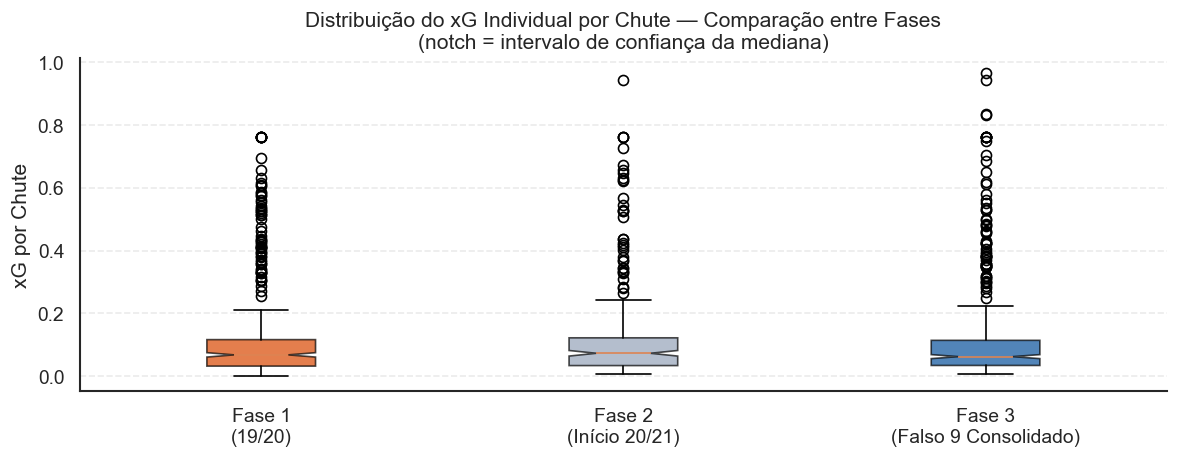

In [13]:
mc_shots['inside_box'] = (mc_shots['x_sb'] >= 102) & (mc_shots['y_sb'].between(18, 62))
mc_shots['is_goal'] = (mc_shots['result'] == 'Goal').astype(int)

def shot_quality_metrics(df, label):
    return {
        'Fase': label,
        'Chutes': len(df),
        'xG médio/chute': df['xg'].mean(),
        'xG total': df['xg'].sum(),
        'Gols': df['is_goal'].sum(),
        'Taxa conversão (%)': df['is_goal'].mean() * 100,
        '% dentro da área': df['inside_box'].mean() * 100,
        'Gols/xG ratio': df['is_goal'].sum() / df['xg'].sum() if df['xg'].sum() > 0 else 0,
    }

metricas = pd.DataFrame([
    shot_quality_metrics(mc_shots[mc_shots['fase'] == fase1_label], fase1_label),
    shot_quality_metrics(mc_shots[mc_shots['fase'] == fase2_label], fase2_label),
    shot_quality_metrics(mc_shots[mc_shots['fase'] == fase3_label], fase3_label),
]).set_index('Fase')

print("=== Métricas de Qualidade de Finalização por Fase ===\n")
print(metricas[['Chutes', 'xG médio/chute', 'Gols', 'Taxa conversão (%)', '% dentro da área', 'Gols/xG ratio']].round(3).to_string())

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Seção 6 — Qualidade de Finalização por Fase', fontsize=13, fontweight='bold')

metricas_plot = [
    ('xG médio/chute',     'xG Médio por Chute',        'Maior = chances de melhor qualidade'),
    ('Taxa conversão (%)', 'Taxa de Conversão (%)',      'Maior = execução mais eficiente'),
    ('% dentro da área',  'Chutes dentro da Área (%)', 'Maior = posicionamento mais qualificado'),
]

for ax, (col, titulo, subtitulo) in zip(axes, metricas_plot):
    valores = metricas[col].reindex(fase_order)
    bars = ax.bar(
        range(len(fase_order)), valores.values,
        color=['#D94801', '#94A3B8', '#08519C'],
        edgecolor='white', linewidth=0.5, width=0.6
    )
    ax.set_xticks(range(len(fase_order)))
    ax.set_xticklabels(
        ['Fase 1\n(19/20)', 'Fase 2\n(Início 20/21)', 'Fase 3\n(Falso 9 Consolidado)'],
        fontsize=9
    )
    ax.set_title(f'{titulo}\n{subtitulo}', fontsize=9, fontweight='bold')
    ax.yaxis.grid(True, linestyle='--', alpha=0.4)
    for bar, val in zip(bars, valores.values):
        if pd.notna(val):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                    f'{val:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print("\n=== Distribuição de xG (boxplot por fase) ===")
fig2, ax2 = plt.subplots(figsize=(10, 4))
data_xg = [
    mc_shots[mc_shots['fase'] == fase1_label]['xg'].dropna().values,
    mc_shots[mc_shots['fase'] == fase2_label]['xg'].dropna().values,
    mc_shots[mc_shots['fase'] == fase3_label]['xg'].dropna().values
    ]
bp = ax2.boxplot(
    data_xg,
    labels=['Fase 1\n(19/20)', 'Fase 2\n(Início 20/21)', 'Fase 3\n(Falso 9 Consolidado)'],
    patch_artist=True, notch=True
)
for patch, color in zip(bp['boxes'], ['#D94801', '#94A3B8', '#08519C']):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax2.set_ylabel('xG por Chute')
ax2.set_title(
    'Distribuição do xG Individual por Chute — Comparação entre Fases\n'
    '(notch = intervalo de confiança da mediana)'
)
ax2.yaxis.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

---
## Seção 6.5 — O Papel dos Pontas: Volume, Qualidade e Movimentação por Fase

> *Com a saída de Agüero do sistema, os pontas precisariam absorver mais responsabilidade ofensiva — mas foi isso que aconteceu?*

Esta seção analisa Sterling, Mahrez, Torres e Sané em três dimensões:

| Dimensão | Gráficos |
|----------|---------|
| **Quantidade** | Chutes por jogo por ponta por fase (6.5.1) |
| **Qualidade** | xG/chute, % dentro da área, distância ao gol, gols/jogo (6.5.2) |
| **Movimentação** | Scatter no campo + KDE de densidade + distribuição esq/dir (6.5.3–5) |

**Hipótese:** na Fase 3 (Falso 9 Consolidado), a participação dos pontas aumenta de forma significativa — eles assumem o espaço antes ocupado por Agüero.

Pontas identificados: ['F. Torres', 'Mahrez', 'Sané', 'Sterling']


Chutes por ponta e fase:
fase        Fase 1 — Agüero titular  Fase 2 — Transição  Fase 3 — Pós-transição
short_name                                                                     
F. Torres                         0                   3                      24
Mahrez                           27                  31                      37
Sané                              2                   0                       0
Sterling                         36                  37                      42


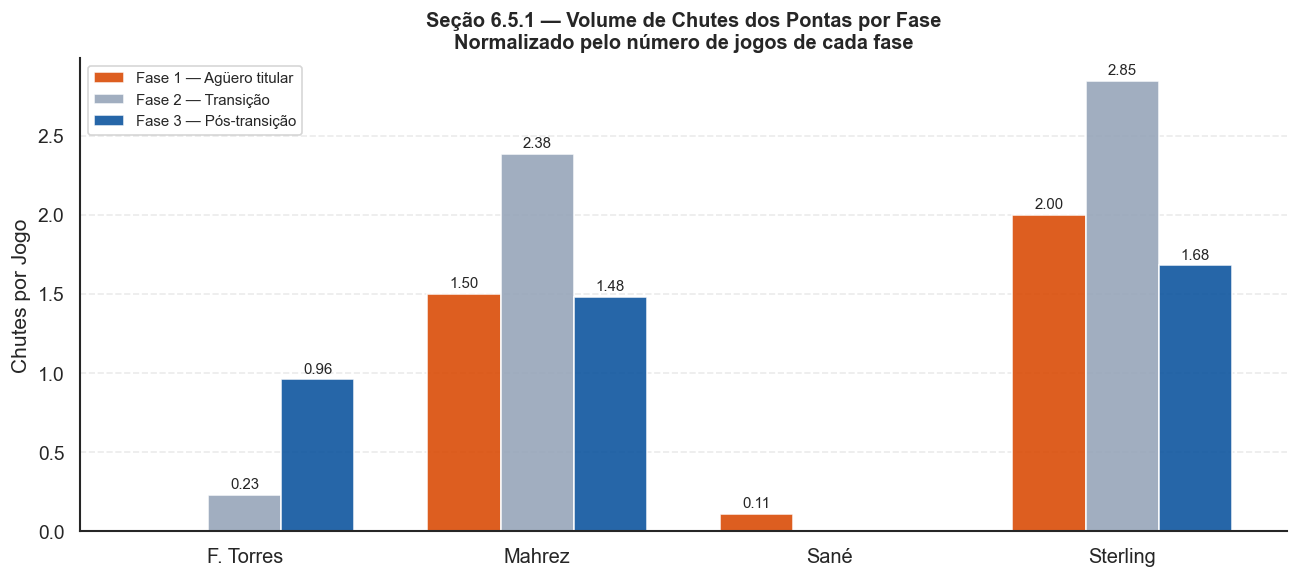


=== Chutes/jogo dos pontas por fase ===
           Fase 1 — Agüero titular  Fase 2 — Transição  Fase 3 — Pós-transição
F. Torres                    0.000               0.231                    0.96
Mahrez                       1.500               2.385                    1.48
Sané                         0.111               0.000                    0.00
Sterling                     2.000               2.846                    1.68

=== Todos os pontas juntos ===
  Fase 1 — Agüero titular: 65 chutes | 3.61/jogo | xG/jogo: 0.53
  Fase 2 — Transição: 71 chutes | 5.46/jogo | xG/jogo: 0.82
  Fase 3 — Pós-transição: 103 chutes | 4.12/jogo | xG/jogo: 0.64


In [15]:
# === 6.5.A — Setup + Volume de Chutes dos Pontas por Fase ===

PONTAS_MAP = {
    'Raheem Sterling': 'Sterling',
    'Riyad Mahrez': 'Mahrez',
    'Leroy Sané': 'Sané',
}

# Capturar Ferrán / Ferran Torres via contains (trata variações de acento)
ponta_shots = mc_shots[
    mc_shots['player'].isin(PONTAS_MAP.keys()) |
    mc_shots['player'].str.contains('Torres', na=False)
].copy()

ponta_shots['short_name'] = ponta_shots['player'].apply(
    lambda p: 'F. Torres' if 'Torres' in p else PONTAS_MAP.get(p, p)
)
ponta_shots['is_goal'] = (ponta_shots['result'] == 'Goal').astype(int)
ponta_shots['inside_box'] = ((ponta_shots['x_sb'] >= 102) & (ponta_shots['y_sb'].between(18, 62)))
ponta_shots['dist_goal'] = np.sqrt((120 - ponta_shots['x_sb'])**2 + (40 - ponta_shots['y_sb'])**2)

jogo_counts = {fase1_label: g1, fase2_label: g2, fase3_label: g3}
ponta_valid = ponta_shots[ponta_shots['fase'].notna()].copy()
all_pontas = sorted(ponta_valid['short_name'].unique())

print(f"Pontas identificados: {all_pontas}")
print("Chutes por ponta e fase:")
print(ponta_valid.groupby(['short_name', 'fase']).size().unstack(fill_value=0).to_string())

# Chutes por jogo por ponta por fase
def spg(fase, player):
    sub = ponta_valid[(ponta_valid['fase'] == fase) & (ponta_valid['short_name'] == player)]
    return len(sub) / jogo_counts[fase]

df_vol = pd.DataFrame({
    f: {w: spg(f, w) for w in all_pontas}
    for f in [fase1_label, fase2_label, fase3_label]
}).fillna(0)

x = np.arange(len(all_pontas))
w = 0.25
fig, ax = plt.subplots(figsize=(11, 5))
for i, (fase, cor) in enumerate(zip([fase1_label, fase2_label, fase3_label], ['#D94801', '#94A3B8', '#08519C'])):
    bars = ax.bar(x + i * w, df_vol[fase].values, w, label=fase, color=cor, edgecolor='white', alpha=0.88)
    for bar in bars:
        h = bar.get_height()
        if h > 0.04:
            ax.text(bar.get_x() + bar.get_width() / 2, h + 0.02,
                    f'{h:.2f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x + w)
ax.set_xticklabels(all_pontas, fontsize=12)
ax.set_ylabel('Chutes por Jogo')
ax.set_title(
    'Seção 6.5.1 — Volume de Chutes dos Pontas por Fase\n'
    'Normalizado pelo número de jogos de cada fase',
    fontsize=12, fontweight='bold'
)
ax.legend(fontsize=9)
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

print("\n=== Chutes/jogo dos pontas por fase ===")
print(df_vol.round(3).to_string())
print("\n=== Todos os pontas juntos ===")
for fase in [fase1_label, fase2_label, fase3_label]:
    sub = ponta_valid[ponta_valid['fase'] == fase]
    print(f"  {fase}: {len(sub)} chutes | {len(sub)/jogo_counts[fase]:.2f}/jogo | xG/jogo: {sub['xg'].sum()/jogo_counts[fase]:.2f}")

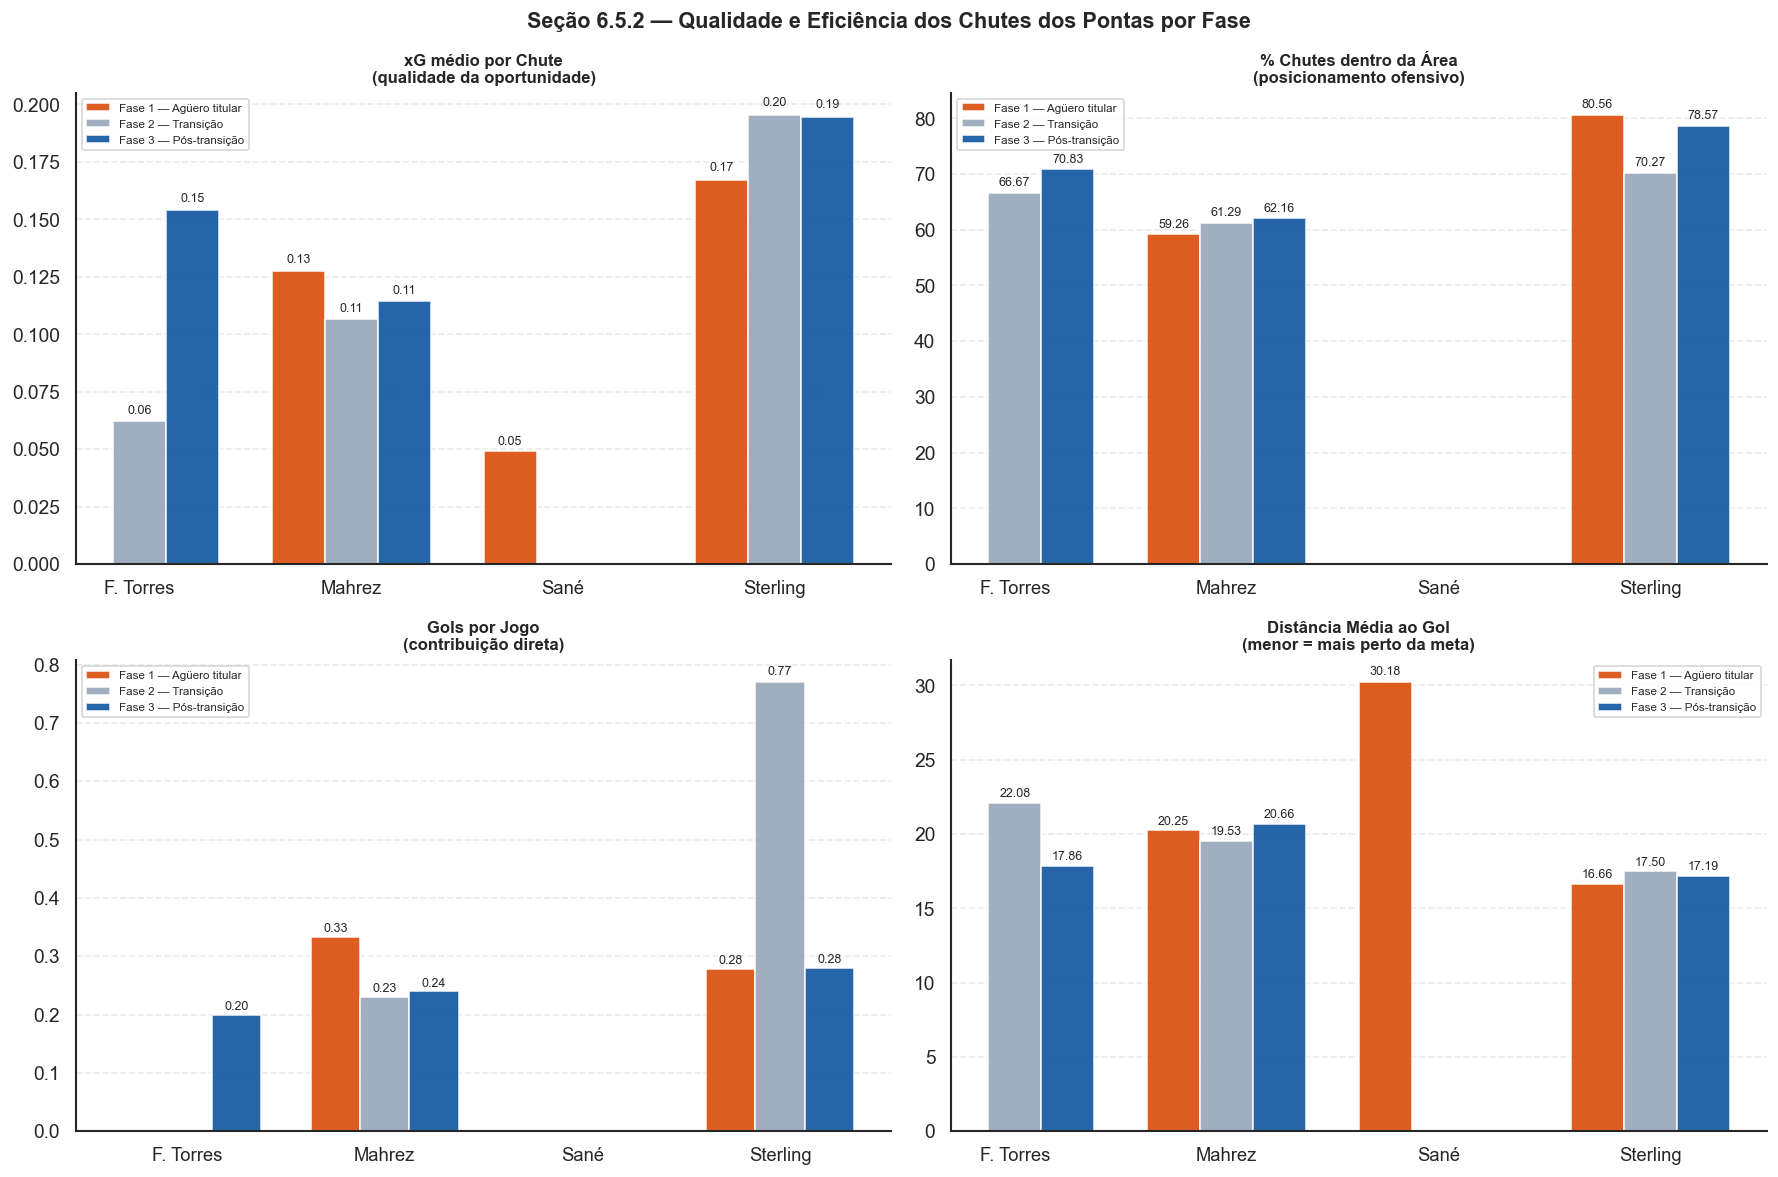

=== Qualidade dos chutes dos pontas por fase ===
        Chutes  xG/chute  Gols  % área  Dist. média  xG/jogo
Fase                                                        
Fase 1      65     0.147    11    69.2         18.6     0.53
Fase 2      71     0.151    13    66.2         18.6     0.82
Fase 3     103     0.156    18    70.9         18.6     0.64


In [16]:
# === 6.5.B — Qualidade e Eficiência dos Chutes dos Pontas ===

def xg_per_shot(fase, player):
    sub = ponta_valid[(ponta_valid['fase'] == fase) & (ponta_valid['short_name'] == player)]
    return sub['xg'].mean() if len(sub) > 0 else np.nan

def box_pct(fase, player):
    sub = ponta_valid[(ponta_valid['fase'] == fase) & (ponta_valid['short_name'] == player)]
    return sub['inside_box'].mean() * 100 if len(sub) > 0 else np.nan

def goals_pg(fase, player):
    sub = ponta_valid[(ponta_valid['fase'] == fase) & (ponta_valid['short_name'] == player)]
    return sub['is_goal'].sum() / jogo_counts[fase] if len(sub) > 0 else 0

def avg_dist(fase, player):
    sub = ponta_valid[(ponta_valid['fase'] == fase) & (ponta_valid['short_name'] == player)]
    return sub['dist_goal'].mean() if len(sub) > 0 else np.nan

metrics_list = [
    ('xG médio por Chute\n(qualidade da oportunidade)', xg_per_shot),
    ('% Chutes dentro da Área\n(posicionamento ofensivo)', box_pct),
    ('Gols por Jogo\n(contribuição direta)', goals_pg),
    ('Distância Média ao Gol\n(menor = mais perto da meta)', avg_dist),
]

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle(
    'Seção 6.5.2 — Qualidade e Eficiência dos Chutes dos Pontas por Fase',
    fontsize=13, fontweight='bold'
)

x = np.arange(len(all_pontas))
w = 0.25

for ax, (titulo, func) in zip(axes.flat, metrics_list):
    for i, (fase, cor) in enumerate(zip([fase1_label, fase2_label, fase3_label], ['#D94801', '#94A3B8', '#08519C'])):
        vals = [func(fase, p) for p in all_pontas]
        bars = ax.bar(x + i * w, vals, w, label=fase, color=cor, edgecolor='white', alpha=0.88)
        for bar, v in zip(bars, vals):
            if pd.notna(v) and v > 0:
                ax.text(bar.get_x() + bar.get_width() / 2,
                        bar.get_height() * 1.01 + 0.001,
                        f'{v:.2f}', ha='center', va='bottom', fontsize=7.5)
    ax.set_xticks(x + w)
    ax.set_xticklabels(all_pontas, fontsize=11)
    ax.set_title(titulo, fontsize=10, fontweight='bold')
    ax.legend(fontsize=7)
    ax.yaxis.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

# Tabela resumo de qualidade
print("=== Qualidade dos chutes dos pontas por fase ===")
rows = []
for fase in [fase1_label, fase2_label, fase3_label]:
    sub = ponta_valid[ponta_valid['fase'] == fase]
    if len(sub) == 0:
        continue
    rows.append({
        'Fase': fase.split(' — ')[0],
        'Chutes': len(sub),
        'xG/chute': round(sub['xg'].mean(), 3),
        'Gols': sub['is_goal'].sum(),
        '% área': round(sub['inside_box'].mean() * 100, 1),
        'Dist. média': round(sub['dist_goal'].mean(), 1),
        'xG/jogo': round(sub['xg'].sum() / jogo_counts[fase], 2),
    })
print(pd.DataFrame(rows).set_index('Fase').to_string())

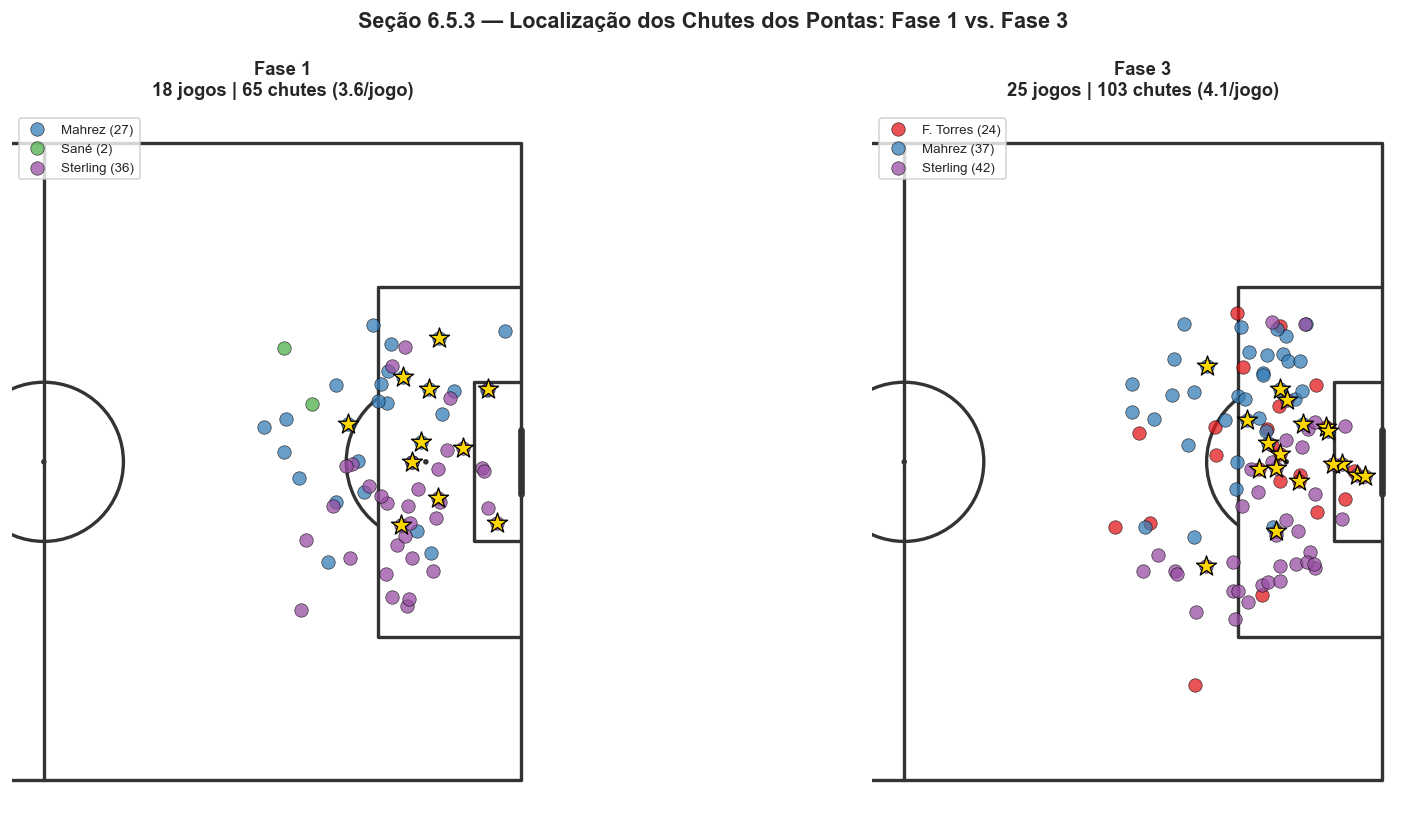

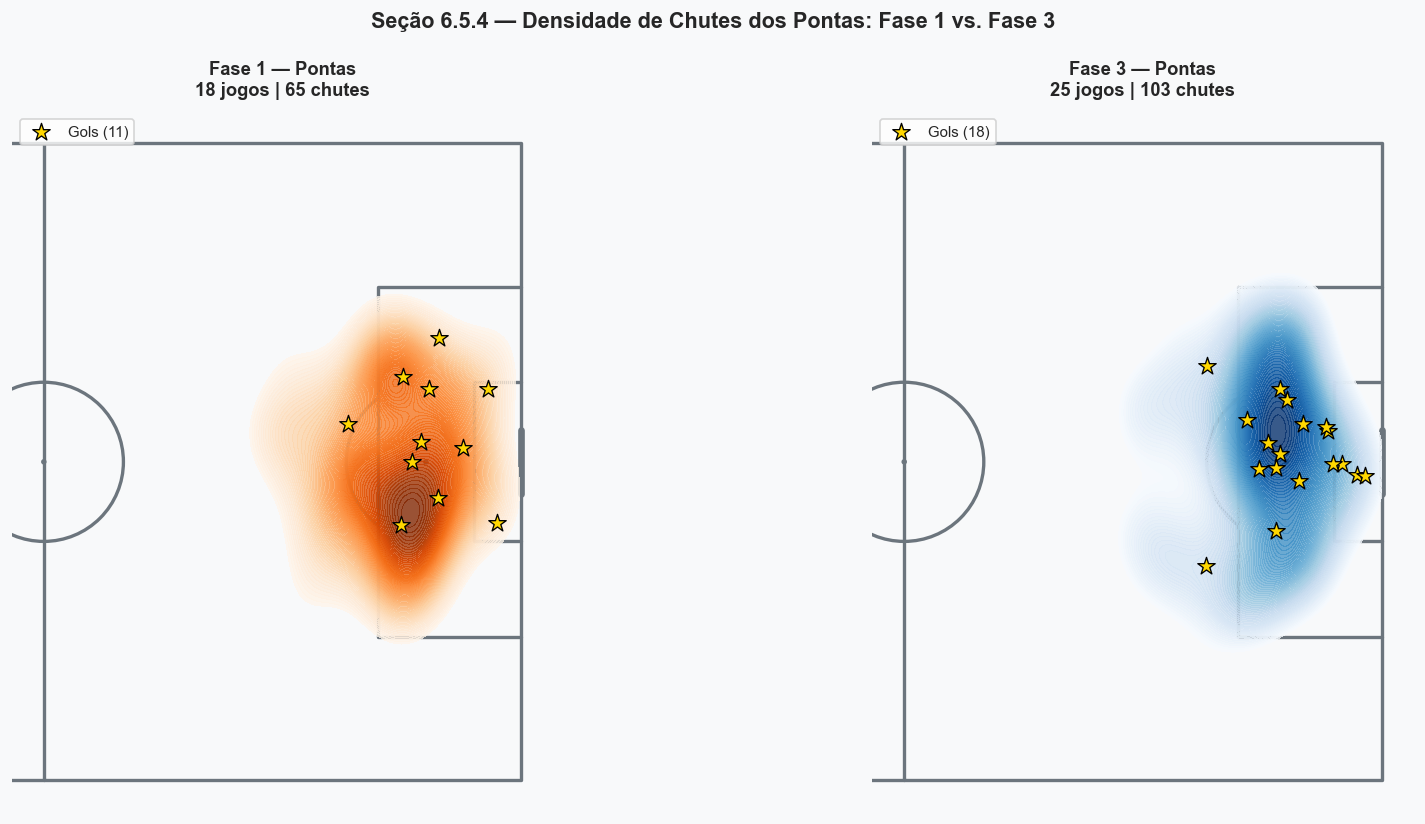

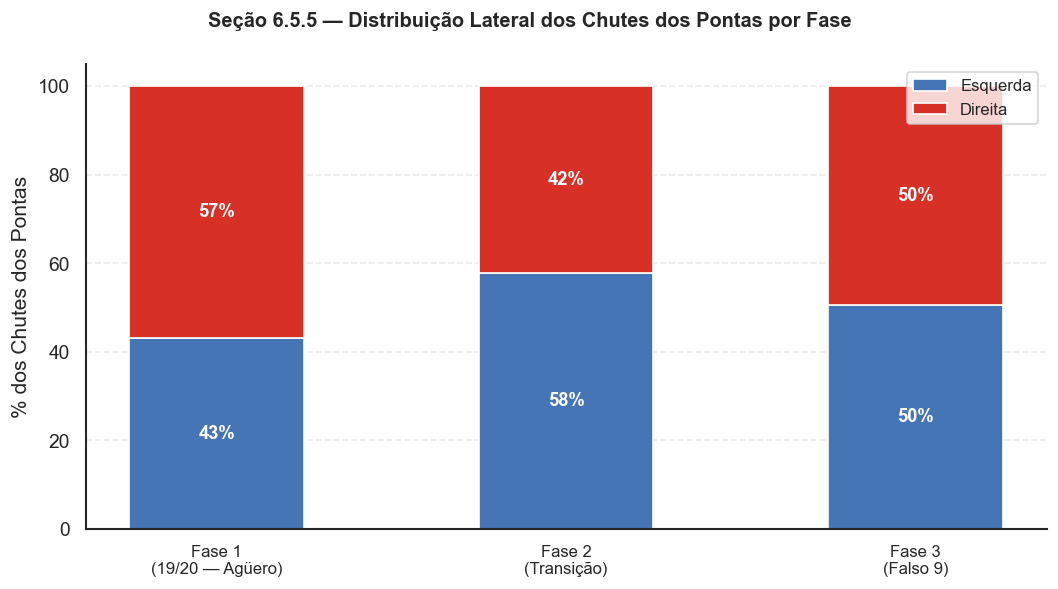

In [17]:
# === 6.5.C — Mapas de Chute + KDE + Distribuição Lateral dos Pontas ===

# Mapa de chutes por ponta: Fase 1 vs Fase 3
ponta_palette = sns.color_palette('Set1', len(all_pontas))
ponta_colors_map = dict(zip(all_pontas, ponta_palette))

fig, axes_p = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Seção 6.5.3 — Localização dos Chutes dos Pontas: Fase 1 vs. Fase 3', fontsize=13, fontweight='bold')
fig.set_facecolor('white')

pitch = Pitch(pitch_type='statsbomb', half=True, pitch_color='white', line_color='#333333')
pitch.draw(ax=axes_p[0])
pitch.draw(ax=axes_p[1])

for ax, fase, n_jogos in [
    (axes_p[0], fase1_label, g1),
    (axes_p[1], fase3_label, g3),
]:
    data_fase = ponta_valid[ponta_valid['fase'] == fase]
    for ponta in all_pontas:
        sub = data_fase[data_fase['short_name'] == ponta]
        if len(sub) == 0:
            continue
        ax.scatter(sub['x_sb'], sub['y_sb'], s=65, color=ponta_colors_map[ponta], alpha=0.75,
                   edgecolors='black', linewidth=0.4, label=f'{ponta} ({len(sub)})', zorder=3)
        gols_sub = sub[sub['is_goal'] == 1]
        if len(gols_sub) > 0:
            ax.scatter(gols_sub['x_sb'], gols_sub['y_sb'], s=160, color='gold',
                       edgecolors='black', linewidth=0.8, marker='*', zorder=5)
    n_chutes = len(data_fase)
    fase_short = fase.split(' — ')[0]
    ax.set_title(f'{fase_short}\n{n_jogos} jogos | {n_chutes} chutes ({n_chutes/n_jogos:.1f}/jogo)',
                 fontsize=11, fontweight='bold', pad=10)
    ax.legend(loc='upper left', fontsize=8, frameon=True, facecolor='white')

plt.tight_layout()
plt.show()

# KDE dos pontas: Fase 1 vs Fase 3
fig2, axes_kde = plt.subplots(1, 2, figsize=(16, 7))
fig2.suptitle('Seção 6.5.4 — Densidade de Chutes dos Pontas: Fase 1 vs. Fase 3', fontsize=13, fontweight='bold')
fig2.set_facecolor('#f8f9fa')

pitch2 = Pitch(pitch_type='statsbomb', half=True, pitch_color='#f8f9fa', line_color='#6c757d')
pitch2.draw(ax=axes_kde[0])
pitch2.draw(ax=axes_kde[1])

for ax, fase, n_jogos, cmap_name in [
    (axes_kde[0], fase1_label, g1, 'Oranges'),
    (axes_kde[1], fase3_label, g3, 'Blues'),
]:
    data_fase = ponta_valid[ponta_valid['fase'] == fase]
    if len(data_fase) >= 5:
        pitch2.kdeplot(data_fase['x_sb'], data_fase['y_sb'], ax=ax,
                       cmap=cmap_name, fill=True, levels=80, thresh=0.1, alpha=0.8)
    gols_fase = data_fase[data_fase['is_goal'] == 1]
    if len(gols_fase) > 0:
        ax.scatter(gols_fase['x_sb'], gols_fase['y_sb'], s=120, color='gold',
                   edgecolors='black', linewidth=0.8, marker='*', zorder=5,
                   label=f'Gols ({len(gols_fase)})')
    fase_short = fase.split(' — ')[0]
    ax.set_title(f'{fase_short} — Pontas\n{n_jogos} jogos | {len(data_fase)} chutes',
                 fontsize=11, fontweight='bold', pad=10)
    ax.legend(loc='upper left', fontsize=9, frameon=True)

plt.tight_layout()
plt.show()

# Distribuição lateral (esquerda / direita) por fase
ponta_valid['side'] = ponta_valid['y_sb'].apply(lambda y: 'Esquerda' if y < 40 else 'Direita')
side_summary = ponta_valid.groupby(['fase', 'side']).size().reset_index(name='n')
side_summary['pct'] = side_summary.groupby('fase')['n'].transform(lambda x: x / x.sum() * 100)
side_pivot = side_summary.pivot(index='fase', columns='side', values='pct').reindex(fase_order).fillna(0)

esq_vals = side_pivot['Esquerda'].values if 'Esquerda' in side_pivot.columns else np.zeros(len(fase_order))
dir_vals = side_pivot['Direita'].values if 'Direita' in side_pivot.columns else np.zeros(len(fase_order))

fig3, ax3 = plt.subplots(figsize=(9, 5))
fig3.suptitle('Seção 6.5.5 — Distribuição Lateral dos Chutes dos Pontas por Fase', fontsize=12, fontweight='bold')
x3 = np.arange(len(fase_order))
ax3.bar(x3, esq_vals, 0.5, color='#4575b4', label='Esquerda', edgecolor='white')
ax3.bar(x3, dir_vals, 0.5, bottom=esq_vals, color='#d73027', label='Direita', edgecolor='white')

for i in range(len(fase_order)):
    if esq_vals[i] > 5:
        ax3.text(i, esq_vals[i] / 2, f'{esq_vals[i]:.0f}%', ha='center', va='center',
                 fontsize=11, color='white', fontweight='bold')
    if dir_vals[i] > 5:
        ax3.text(i, esq_vals[i] + dir_vals[i] / 2, f'{dir_vals[i]:.0f}%', ha='center', va='center',
                 fontsize=11, color='white', fontweight='bold')

ax3.set_xticks(x3)
ax3.set_xticklabels(['Fase 1\n(19/20 — Agüero)', 'Fase 2\n(Transição)', 'Fase 3\n(Falso 9)'], fontsize=10)
ax3.set_ylabel('% dos Chutes dos Pontas')
ax3.legend(fontsize=10)
ax3.yaxis.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

---
## Seção 7 — Conclusão: A Zona como Centroavante

Esta investigação partiu de uma hipótese provocadora: a lesão de Sergio Agüero não enfraqueceu o Manchester City — ela revelou a estrutura profunda de um sistema que não dependia de um centroavante fixo para funcionar.

### Evidências consolidadas

| Dimensão | Análise | Evidência |
|----------|---------|----------|
| **Espacial** | KDE (Seções 1–2) | Zonas de finalização estáveis entre 2019/20 e Falso 9 |
| **Distribuição** | Chutes por jogador/jogo | Meias aumentaram; atacantes de ofício diminuíram |
| **Posicional** | Finalização por posição | Meio-campo absorveu a função do centroavante |
| **Concentração** | Índice HHI | HHI menor na Fase 3 — maior coletivismo ofensivo |
| **Funcional** | Caso Gündogan | Meia tornou-se artilheiro atuando nas zonas do 9 |
| **Qualidade** | xG por chute | Manutenção ou elevação da qualidade das chances |

### Tese Central

> **"No sistema de Guardiola, a zona exerce o papel do centroavante."**

A comparação entre as temporadas 2019/20 (com Agüero) e 2020/21 (falso 9 consolidado) confirma que a transformação foi estrutural — não foi uma adaptação emergencial, mas a revelação de um princípio de jogo latente.

### Limitações Metodológicas

- **Dados apenas de finalização:** o Understat fornece somente eventos de chute. Análises de posse, pressão e passes progressivos requerem fontes como Statsbomb ou Wyscout.
- **Comparação entre temporadas:** diferenças de calendário, adversários, elenco (saída de David Silva) e COVID entre 19/20 e 20/21 são variáveis de confusão.
- **Causalidade vs. correlação:** os dados mostram que as mudanças se intensificaram após a lesão de Agüero, mas não isolam causalidade direta.